# **European Drugs Development**

Team 10: Samuel Buelvas, Chamnan Suon, Gurveen Rekhi, Roberto Albornoz

## **Executive Summary**

Drug development in Europe plays a crucial role in shaping the pharmaceutical industry both in Europe and around the world. By understanding the behaviors of drug development stages and regulatory processes, we could uncover patterns and trends which would ultimately allow companies to better develop business strategies and adjust its internal process in order to optimize the successful implementation of the development.

Preliminary exploratory data analysis (EDA) was conducted on the European Medicines Agency (EMA) dataset to understand the portfolio structure and ensure the data support unsupervised learning. We began by examining authorization trends over time and expanding therapeutic area classifications to observe how the regulatory landscape has evolved. The time-series view highlights periods of acceleration and reveals whether surges in approvals are aligned with specific dominant disease areas or reflect broader diversification, directly informing our investigation into authorization trends.

Next, we assessed market concentration by identifying which marketing authorization holders account for the highest volume of medicines. This step determines whether approvals are broadly distributed across the industry or concentrated among a small group of firms. Understanding this distribution provides a baseline for segmenting companies in later stages, specifically to explore if certain portfolios or regulatory capabilities correlate with higher authorization accumulation.

Finally, we compared patterns between human and veterinary medicines and evaluated the variability of the unstructured indication text. We confirmed that the text descriptions contain sufficient length and diversity to support Natural Language Processing (NLP) tasks. This validates the project’s plan to use topic modeling to discover latent disease themes and niche clusters that are not fully captured by structured therapeutic labels alone.

## **Data Dictionary**

# `drugs_dataset.csv`

|Column  |Class      |Description          |
|:-------|:----------|:--------------------|
|category|character | human or veterinary|
|medicine_name | character | brand name of the medicine|
|therapeutic_area | character | semicolon-separated list of therapeutic areas|
|common_name | character | international non-proprietary name (INN) or common name|
|active_substance | character | common name of the active chemical in the drug|
|product_number | character | EMEA/H/C/ (human) or EMEA/V/C/ (veterinary) number for the drug|
|patient_safety | logical | has patient safety notices|
|authorisation_status | character | whether the drug was authorised, withdrawn, or refused (or does not have a reported status)|
|atc_code | character | anatomical therapeutic chemical code|
|additional_monitoring | logical | when true, the medicine is under additional monitoring, meaning that it is monitored even more intensively than other medicines|
|generic | logical | whether the drug is a generic medicine, which is developed to be the same as a medicine that has already been authorised, called the reference medicine. A generic medicine contains the same active substance(s) as the reference medicine, and is used at the same dose(s) to treat the same disease(s)|
|biosimilar | logical | whether the drug is a biosimilar medicine, which is a biological medicine highly similar to another already approved biological medicine called the reference medicine.|
|conditional_approval | logical | whether the medicine received a conditional marketing authorisation. This was granted in the interest of public health because the medicine addresses an unmet medical need and the benefit of immediate availability outweighs the risk from less comprehensive data than normally required.|
|exceptional_circumstances | logical | whether the medicine was authorised under exceptional circumstances, because the applicant was unable to provide comprehensive data on the efficacy and safety of the medicine under normal conditions of use. This can happen because the condition to be treated is rare or because collection of full information is not possible or is unethical.|
|accelerated_assessment | logical | whether the medicine had an accelerated assessment. This means that it is a medicine of major interest for public health, so its timeframe for review was 150 evaluation days rather than 210.|
|orphan_medicine | logical | whether the medicine was designated an orphan medicine. This means that it was developed for use against a rare, life-threatening or chronically debilitating condition or, for economic reasons, it would be unlikely to have been developed without incentives.|
|marketing_authorisation_date | date | date on which the drug was authorised|
|date_of_refusal_of_marketing_authorisation | date | date on which the drug was refused|
|marketing_authorisation_holder_company_name | character | name of the company that is authorised to market the drug|
|pharmacotherapeutic_group | character | the target of the drug|
|date_of_opinion | date | date on which the opinion was made|
|decision_date | date | date on which the latest decision was made|
|revision_number | integer | integer revision number|
|condition_indication | character | language describing the specific uses of the drug|
|species | character | for veterinary medicines, the target species; might benefit from further cleaning|
|first_published | datetime | datetime when the information was first published|
|revision_date | datetime | datetime of the most recent revision|
|url | character | url for details about the drug and submission|

## **Load Data**

In [160]:
# Import pandas and numpy for DataFrame and operations
import pandas as pd
import numpy as np


In [161]:
import warnings

# Filter by category only (less precise, but very effective)
warnings.filterwarnings("ignore", category=DeprecationWarning)

# Option A: The most precise regex fix (using the 'r' prefix for raw string)
warnings.filterwarnings("ignore", message=r"datetime\.datetime\.utcnow.*", category=DeprecationWarning)

# Option B: Target the specific library causing the spam (very effective in Colab)
warnings.filterwarnings("ignore", category=DeprecationWarning, module="jupyter_client")

In [162]:
# Load dataset from github relative path
path = "https://raw.githubusercontent.com/SChamnan/ba820-unsupervised-ml-team10-project/refs/heads/main/european-drugs-development/drugs-dataset.csv"
drugs_df = pd.read_csv(path)

# Check out the first 5 rows of data
drugs_df.head(5)

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,marketing_authorisation_holder_company_name,pharmacotherapeutic_group,date_of_opinion,decision_date,revision_number,condition_indication,species,first_published,revision_date,url
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,Takeda Pharma A/S,Antineoplastic agents,2012-07-19,2022-11-17,34.0,Hodgkin lymphomaAdcetris is indicated for adul...,NaN,2018-07-25T13:58:00Z,2023-03-13T11:52:00Z,https://www.ema.europa.eu/en/medicines/human/E...
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,Cycle Pharmaceuticals (Europe) Ltd,"Other alimentary tract and metabolism products,",2018-05-31,2023-03-10,4.0,Treatment of adult and paediatric patients wit...,NaN,2018-07-26T14:20:00Z,2023-03-10T17:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,NaN,True,...,Pierre Fabre Medicament,NaN,2022-10-13,2023-03-09,2.0,Ebvallo is indicated as monotherapy for treatm...,NaN,2022-10-12T16:13:00Z,2023-03-10T13:40:00Z,https://www.ema.europa.eu/en/medicines/human/E...
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,Roche Registration GmbH,"Immune sera and immunoglobulins,",2021-11-11,2023-02-24,3.0,Ronapreve is indicated for:Treatment of COVID-...,NaN,2021-11-12T16:30:00Z,2023-03-10T12:29:00Z,https://www.ema.europa.eu/en/medicines/human/E...
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,Novartis Europharm Limited,Immunosuppressants,2014-11-20,2023-01-26,30.0,Plaque psoriasisCosentyx is indicated for the ...,NaN,2018-06-07T11:59:00Z,2023-03-09T18:53:00Z,https://www.ema.europa.eu/en/medicines/human/E...


## **Data Cleaning and Preprocessing**

In [163]:
# Check number of rows and columns
drugs_df.shape

(1988, 28)

In [164]:
drugs_df.describe()

,product_number,revision_number
count,1988.000000,1892.000000
mean,2634.774145,13.527484
std,1915.734686,11.647056
min,24.000000,0.000000
25%,715.750000,4.750000
50%,2544.500000,11.000000
75%,4351.000000,19.000000
max,6039.000000,89.000000


Below shows number of missing values in each column. These missing values could be either removed or keep as they are. Imputation may not be the best option as it may misrepresenting data.

In [165]:
# Chart showing missing values of each column
missing_values = drugs_df.isnull().sum()
missing_percentage = ((drugs_df.isnull().sum() / len(drugs_df)) * 100).round(2)

missing_info = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})

display(missing_info.sort_values(by='Missing Count', ascending=False))

,Missing Count,Missing Percentage (%)
date_of_refusal_of_marketing_authorisation,1913,96.23
species,1709,85.97
date_of_opinion,779,39.19
therapeutic_area,285,14.34
revision_number,96,4.83
marketing_authorisation_date,60,3.02
decision_date,45,2.26
pharmacotherapeutic_group,34,1.71
revision_date,29,1.46
atc_code,28,1.41


In [166]:
# Information of values of the variable 'species'
unique_species_with_nan = drugs_df['species'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'species' column:")
print(unique_species_with_nan)


Unique values and their counts (including NaN) in 'species' column:
species
NaN                                                                    1709
Dogs                                                                     70
Cats                                                                     28
Pigs                                                                     25
Dogs; Cats                                                               18
Horses                                                                   18
Chicken                                                                  15
Cattle                                                                   10
Cattle; Pigs; Sheep                                                       7
Sheep; Cattle                                                             6
Cats; Dogs                                                                5
Sheep                                                                     5
Rabbits    

In [167]:
# Get the count of all unique values, including NaN, for 'authorisation_status'
unique_auth_status_with_nan = drugs_df['authorisation_status'].value_counts(dropna=False)
print("Unique values and their counts (including NaN) in 'authorisation_status' column:")
print(unique_auth_status_with_nan)

# You can apply the same to other columns as needed, for example 'category'
unique_category_with_nan = drugs_df['category'].value_counts(dropna=False)
print("\nUnique values and their counts (including NaN) in 'category' column:")
print(unique_category_with_nan)

Unique values and their counts (including NaN) in 'authorisation_status' column:
authorisation_status
authorised    1573
withdrawn      357
refused         57
NaN              1
Name: count, dtype: int64

Unique values and their counts (including NaN) in 'category' column:
category
human         1706
veterinary     282
Name: count, dtype: int64


### **Categorization of the Columns**

In [168]:
# Categorize columns type
# Category cols
cat_cols = ["category",
            "medicine_name",
            "common_name",
            "active_substance",
            "authorisation_status",
            "atc_code",
            "marketing_authorisation_holder_company_name"]

#text cols
text_cols = ["condition_indication"]

# id cols
id_cols = ["url", "product_number"]

# list text cols
list_text_cols = ["therapeutic_area",
                  "pharmacotherapeutic_group",
                  "species"]

# Numeric cols
numeric_cols = ["revision_number"]

# Boolean cols
boolean_cols = ["patient_safety",
                "additional_monitoring",
                "generic",
                "biosimilar",
                "conditional_approval",
                "exceptional_circumstances",
                "accelerated_assessment",
                "orphan_medicine",
                ]

# Datetime cols
datetime_cols = ["marketing_authorisation_date",
             "date_of_refusal_of_marketing_authorisation",
             "date_of_opinion",
             "decision_date",
             "revision_date",
             "first_published"]


### **Preparing data for Analysis**

In [169]:

def clean_string_series(s):
    """
    Standard string cleanup:
    - converts to pandas 'string' dtype
    - normalizes whitespace (multiple spaces -> one)
    - trims leading/trailing whitespace
    """
    s = s.astype("string")
    s = s.str.replace(r"\s+", " ", regex=True).str.strip()
    return s

def to_bool_series(s):
    """
    Robust boolean conversion:
    Handles columns that might be stored as:
    - True/False
    - 1/0
    - 'TRUE'/'FALSE'
    - 'Yes'/'No'
    Missing values are treated as False (safe default for these regulatory flags).
    """
    if s.dtype == bool:
        return s.fillna(False)

    s_str = s.astype("string")
    s_norm = s_str.str.strip().str.lower()

    true_set = {"true", "t", "1", "yes", "y"}
    false_set = {"false", "f", "0", "no", "n", ""}

    out = pd.Series(pd.NA, index=s.index, dtype="boolean")
    out = out.mask(s_norm.isin(true_set), True)
    out = out.mask(s_norm.isin(false_set), False)

    # fallback numeric coercion for any remaining NAs
    if out.isna().any():
        num = pd.to_numeric(s_str, errors="coerce")
        out = out.fillna(num.eq(1))

    return out.fillna(False).astype(bool)

def clean_list_text_column(s):
    """
    Cleanup for semicolon-separated list fields like:
    therapeutic_area, pharmacotherapeutic_group, species.
    - normalizes whitespace
    - standardizes delimiter spacing: "A;B" -> "A; B"
    """
    s = clean_string_series(s)
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

def clean_species_column(s):
    """
    Extra cleanup for species:
    - removes parenthetical qualifiers: 'Pigs (for fattening)' -> 'Pigs'
    - standardizes semicolon spacing: 'Dogs;Cats' -> 'Dogs; Cats'
    """
    s = clean_list_text_column(s)
    s = s.str.replace(r"\s*\(.*?\)\s*", "", regex=True).str.strip()
    s = s.str.replace(r"\s*;\s*", "; ", regex=True)
    return s

**clean_string_series(s)**
This function cleans a text column in a consistent way. It converts the column to a string type, replaces multiple spaces with a single space, and removes extra spaces at the beginning and end of each value. This helps avoid errors caused by inconsistent spacing.

**to_bool_series(s)**
This function converts a column into True/False values even if the column is stored in different formats. It can handle values like True/False, 1/0, and text like "yes"/"no" or "true"/"false". Missing values are treated as False to keep regulatory flag columns safe and consistent for later analysis.

**clean_list_text_column(s)**
This function cleans columns that contain lists stored as text using semicolons (for example: "A;B"). It first applies basic text cleaning (spacing and trimming). Then it standardizes the semicolon format so items are separated as "; " (semicolon + one space). This makes splitting the list later more reliable.

**clean_species_column(s)**
This function is a specialized cleaner for the species column. It applies the semicolon list cleaning, removes extra text written inside parentheses (for example: "Pigs (for fattening)" becomes "Pigs"), and standardizes semicolon spacing again. This produces a cleaner and more consistent species field for later grouping and analysis.

### **Cleaning & Type casting columns**

In [170]:
drugs_df = drugs_df.copy()

# Clean category/text/id columns (trim + normalize spacing)
for c in (cat_cols + text_cols + id_cols):
    if c in drugs_df.columns:
        drugs_df[c] = clean_string_series(drugs_df[c])

# Clean list-text columns
for c in list_text_cols:
    if c in drugs_df.columns:
        if c == "species":
            drugs_df[c] = clean_species_column(drugs_df[c])
        else:
            drugs_df[c] = clean_list_text_column(drugs_df[c])

# Standardize small categorical fields
if "category" in drugs_df.columns:
    drugs_df["category"] = drugs_df["category"].astype("string").str.lower().str.strip()

if "authorisation_status" in drugs_df.columns:
    drugs_df["authorisation_status"] = drugs_df["authorisation_status"].astype("string").str.lower().str.strip()

if "atc_code" in drugs_df.columns:
    drugs_df["atc_code"] = drugs_df["atc_code"].astype("string").str.upper().str.strip()

# Cast booleans group
for c in boolean_cols:
    if c in drugs_df.columns:
        drugs_df[c] = to_bool_series(drugs_df[c])


# Cast numeric group
for c in numeric_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_numeric(drugs_df[c], errors="coerce").astype("Int64")


# Cast datetimes group
for c in datetime_cols:
    if c in drugs_df.columns:
        drugs_df[c] = pd.to_datetime(drugs_df[c], errors="coerce")


# Quick checks
print("Category counts:\n", drugs_df["category"].value_counts(dropna=False), "\n")
print("Status counts:\n", drugs_df["authorisation_status"].value_counts(dropna=False), "\n")
if "species" in drugs_df.columns:
    print("Top species values:\n", drugs_df["species"].value_counts(dropna=False).head(10))


Category counts:
 category
human         1706
veterinary     282
Name: count, dtype: Int64 

Status counts:
 authorisation_status
authorised    1573
withdrawn      357
refused         57
<NA>             1
Name: count, dtype: Int64 

Top species values:
 species
<NA>                   1709
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: Int64


**Clean category/text/id columns**
Since text fields can include extra spaces or inconsistent spacing, we clean these columns by standardizing whitespace and trimming leading and trailing spaces.

**Clean list-text columns**
Since some fields store multiple values in one cell using semicolons, we standardize the formatting of these list-style columns so they are consistent. For species, we also remove text inside parentheses to keep the names clean.

**Standardize small categorical fields**
Since category and authorisation_status may appear with different capitalization or spaces, we convert them to lowercase and trim spaces. Since atc_code should follow a consistent code format, we convert it to uppercase and trim spaces.

**Cast columns (booleans, numeric, and datetime)**
Since some columns may be stored with inconsistent data types (for example, booleans as text, numbers as strings, or dates in mixed formats), we convert boolean, numeric, and datetime columns into consistent types. Any values that cannot be converted are set to missing to avoid errors in later analysis.

**Quick checks**
Since we want to confirm the cleaning worked, we print basic value counts for category, authorisation_status, and the most common species values.

### **Create Derived columns for Analysis**

In [171]:
# Shared / Computed derived columns
drugs_df["category_clean"] = drugs_df["category"].astype("string").str.strip().str.lower().fillna("unknown")
drugs_df["authorisation_status_clean"] = drugs_df["authorisation_status"].astype("string").str.strip().str.lower().fillna("unknown")

drugs_df["is_veterinary"] = (drugs_df["category_clean"] == "veterinary").astype(int)
drugs_df["is_authorised"] = (drugs_df["authorisation_status_clean"] == "authorised").astype(int)
drugs_df["is_withdrawn"]  = (drugs_df["authorisation_status_clean"] == "withdrawn").astype(int)
drugs_df["is_refused"]    = (drugs_df["authorisation_status_clean"] == "refused").astype(int)


# Map diseases being targeted (Indication NLP readiness)
drugs_df["condition_indication_clean"] = (
    drugs_df["condition_indication"]
      .fillna("")
      .astype("string")
      .str.replace(r"\s+", " ", regex=True)
      .str.strip()
      .str.lower()
)
drugs_df["indication_length"] = drugs_df["condition_indication_clean"].str.len().astype(int)

# Helpful for interpretation later
drugs_df["therapeutic_area_list"] = drugs_df["therapeutic_area"].apply(
    lambda x: [] if pd.isna(x) or str(x).strip() == ""
    else sorted(set([p.strip().lower() for p in str(x).split(";") if p.strip()]))
)
drugs_df["pharm_group_list"] = drugs_df["pharmacotherapeutic_group"].apply(
    lambda x: [] if pd.isna(x) or str(x).strip() == ""
    else sorted(set([p.strip().lower() for p in str(x).split(";") if p.strip()]))
)
drugs_df["pharm_group_count"] = drugs_df["pharm_group_list"].apply(len).astype(int)
drugs_df["therapeutic_area_count"] = drugs_df["therapeutic_area_list"].apply(len).astype(int)
drugs_df["missing_therapeutic_area"] = drugs_df["therapeutic_area"].isna().astype(int)

drugs_df["atc_code_clean"] = drugs_df["atc_code"].astype("string").str.strip().str.upper()
drugs_df["atc_level1"] = drugs_df["atc_code_clean"].str[0]
drugs_df["atc_level2"] = drugs_df["atc_code_clean"].str[:3].where(drugs_df["atc_code_clean"].str.len() >= 3, pd.NA)
drugs_df["missing_atc_code"] = drugs_df["atc_code"].isna().astype(int)

# What types of medicines get special approvals?
pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

drugs_df["special_pathway_count"] = drugs_df[pathway_cols].sum(axis=1).astype(int)

def make_pathway_profile(row):
    active = [c for c in pathway_cols if bool(row[c])]
    return "+".join(active) if active else "none"

drugs_df["pathway_profile"] = drugs_df.apply(make_pathway_profile, axis=1)

# Human vs veterinary + veterinary species segmentation
drugs_df["species_clean"] = np.where(
    drugs_df["category_clean"] == "human",
    "human",
    drugs_df["species"].astype("string").str.strip()
)

drugs_df["missing_species_vet"] = (
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna())
).astype(int)

drugs_df["species_clean"] = np.where(
    (drugs_df["category_clean"] == "veterinary") & (drugs_df["species_clean"].isna()),
    "unknown",
    drugs_df["species_clean"]
)

vet = drugs_df[drugs_df["category_clean"]=="veterinary"].copy()

vet["missing_atc2"] = vet["atc_level2"].isna().astype(int)
vet["missing_pg"] = vet["pharm_group_list"].apply(lambda x: 1 if (not isinstance(x, list) or len(x)==0) else 0)
vet[["missing_atc2","missing_pg"]].mean().to_frame("pct").mul(100).round(2)

# Missingness flags for clustering diagnostics
drugs_df["missing_atc2"] = drugs_df["atc_level2"].isna().astype(int)
drugs_df["missing_pg"] = drugs_df["pharm_group_list"].apply(
    lambda x: 1 if (not isinstance(x, list) or len(x)==0) else 0
)

# check only for veterinary
drugs_df.loc[drugs_df["category_clean"]=="veterinary", ["missing_atc2","missing_pg"]].mean().to_frame("pct").mul(100).round(2)



drugs_df["species_list"] = drugs_df["species_clean"].apply(
    lambda v: [] if pd.isna(v) or v in ["human", "unknown", ""]
    else sorted(set([p.strip().lower() for p in str(v).split(";") if p.strip()]))
)
drugs_df["species_count"] = drugs_df["species_list"].apply(len).astype(int)
drugs_df["multi_species_flag"] = (drugs_df["species_count"] > 1).astype(int)

# Quick checks
print("Derived status flag sum counts:\n",
      (drugs_df[["is_authorised", "is_withdrawn", "is_refused"]].sum(axis=1)).value_counts(dropna=False))

print("\nMissing species in veterinary rows:", drugs_df["missing_species_vet"].sum())
print("\nTop species_clean values:\n", drugs_df["species_clean"].value_counts(dropna=False).head(10))


Derived status flag sum counts:
 1    1987
0       1
Name: count, dtype: int64

Missing species in veterinary rows: 3

Top species_clean values:
 species_clean
human                  1706
Dogs                     71
Pigs                     36
Cats                     28
Dogs; Cats               18
Horses                   18
Chicken                  15
Cattle                   12
Cattle; Pigs; Sheep       7
Sheep; Cattle             6
Name: count, dtype: int64


**Clean and standardize key categorical fields**
Since categories may have extra spaces or different capitalization, we create category_clean by trimming, converting to lowercase, and replacing missing values with "unknown" so values like “Human” and “human” are treated the same.

Since authorisation_status is used to compare outcomes across medicines, we create authorisation_status_clean by trimming, converting to lowercase, and replacing missing values with "unknown" to support reliable grouping and analysis.

**Create simple indicator (0/1) variables**
Since unsupervised methods work better with numeric inputs than text labels, we create is_veterinary as a 0/1 indicator based on category_clean.

Since we often need quick counts by status, we create is_authorised, is_withdrawn, and is_refused as 0/1 indicators from authorisation_status_clean, where "unknown" results in all three indicators being 0.

**Prepare indication text for NLP and quality checks**
Since condition_indication is free text with inconsistent spacing and casing, we create condition_indication_clean by filling missing values with an empty string, normalizing spaces, trimming, and converting to lowercase so it is ready for NLP steps.

Since indications can be very short or very long, we compute indication_length as the character length of condition_indication_clean to support basic checks and descriptive analysis.

**Therapeutic area processing**
Since therapeutic_area is stored as a semicolon-separated list, we create therapeutic_area_list by splitting on semicolons, trimming and lowercasing items, and removing duplicates to get a clean set of areas per medicine.

Since medicines can be linked to one or many therapeutic areas, we compute therapeutic_area_count to measure how many areas each medicine has.

Since missing therapeutic_area values may affect interpretation, we create missing_therapeutic_area as a 0/1 indicator to track where this field is absent.

**ATC code standardization and hierarchy**
Since ATC codes can have inconsistent formatting, we create atc_code_clean by trimming and converting to uppercase so codes match consistently.

Since ATC codes are hierarchical, we create atc_level1 (first character) and atc_level2 (first three characters) to support analysis at different levels.

Since some medicines may not have an ATC code recorded, we create missing_atc_code as a 0/1 indicator to track missingness.

**Special regulatory pathway features**
Since a medicine can have multiple pathway flags at the same time, we compute special_pathway_count by summing these flags to measure how many special pathways apply.

Since it is useful to interpret the exact combination of pathways, we create pathway_profile as a label listing all active pathway flags for each medicine.

**Species cleaning and veterinary segmentation**
Since species is not applicable for human medicines, we set species_clean to "human" when category_clean is "human" so it is not treated as missing.

Since some veterinary medicines have missing species values, we create missing_species_vet to flag veterinary rows where species is missing.

Since veterinary rows should have an explicit value even when species is missing, we replace missing veterinary species values with "unknown" in species_clean.

Since species may include multiple values separated by semicolons, we create species_list by splitting, trimming, lowercasing, and removing duplicates to form a clean list per medicine.

Since multi-species products may behave differently than single-species products, we compute species_count and multi_species_flag to measure and flag medicines that target more than one species.

**Quick checks**
Since we need to confirm the derived status flags behave as expected, we print the distribution of the sum of is_authorised, is_withdrawn, and is_refused to verify most rows have exactly one active status and "unknown" rows have zero.

Since we want to confirm veterinary species missingness is small and isolated, we print the total count of missing_species_vet.

Since we want a quick view of species after cleaning, we print the most common values in species_clean.

### **Data Overview After Cleaning**

In [172]:
# show size, missingness, imbalance, and what fields are “strong enough” to analyze.
# Shape
print("Rows, Columns:", drugs_df.shape)

# Missingness table (top missing)
missing = drugs_df.isna().mean().sort_values(ascending=False).to_frame("missing_pct")
missing["missing_pct"] = (missing["missing_pct"] * 100).round(2)
print(missing.head(15))

# Uniqueness checks
print("Unique product_number:", drugs_df["product_number"].nunique(dropna=False))
print("Unique url:", drugs_df["url"].nunique(dropna=False))

Rows, Columns: (1988, 54)
                                             missing_pct
date_of_refusal_of_marketing_authorisation         96.23
species                                            85.97
date_of_opinion                                    39.19
therapeutic_area                                   14.34
revision_number                                     4.83
marketing_authorisation_date                        3.02
decision_date                                       2.26
pharmacotherapeutic_group                           1.71
revision_date                                       1.46
atc_code                                            1.41
atc_code_clean                                      1.41
atc_level1                                          1.41
atc_level2                                          1.41
condition_indication                                0.60
marketing_authorisation_holder_company_name         0.20
Unique product_number: 1932
Unique url: 1988


In [173]:
drugs_df.head()

,category,medicine_name,therapeutic_area,common_name,active_substance,product_number,patient_safety,authorisation_status,atc_code,additional_monitoring,...,missing_atc_code,special_pathway_count,pathway_profile,species_clean,missing_species_vet,missing_atc2,missing_pg,species_list,species_count,multi_species_flag
0,human,Adcetris,"Lymphoma, Non-Hodgkin; Hodgkin Disease",brentuximab vedotin,brentuximab vedotin,2455,False,authorised,L01XC12,False,...,0,1,orphan_medicine,human,0,0,0,[],0,0
1,human,Nityr,Tyrosinemias,nitisinone,nitisinone,4582,False,authorised,A16AX04,False,...,0,0,none,human,0,0,0,[],0,0
2,human,Ebvallo,Lymphoproliferative Disorders,tabelecleucel,tabelecleucel,4577,False,authorised,<NA>,True,...,1,3,orphan_medicine+exceptional_circumstances+addi...,human,0,1,1,[],0,0
3,human,Ronapreve,COVID-19 virus infection,"casirivimab, imdevimab","casirivimab, imdevimab",5814,False,authorised,J06BD,True,...,0,1,additional_monitoring,human,0,0,0,[],0,0
4,human,Cosentyx,"Arthritis, Psoriatic; Psoriasis; Spondylitis, ...",secukinumab,secukinumab,3729,False,authorised,L04AC10,False,...,0,0,none,human,0,0,0,[],0,0


Dataset is cleaned and is ready for next steps.

## **Exploratory Data Analysis**

In [174]:
# Import libraries for plotting
import matplotlib.pyplot as plt

### **Authorized drugs trend over time**

Viewing trend of drugs being authorized to be marketed over time.

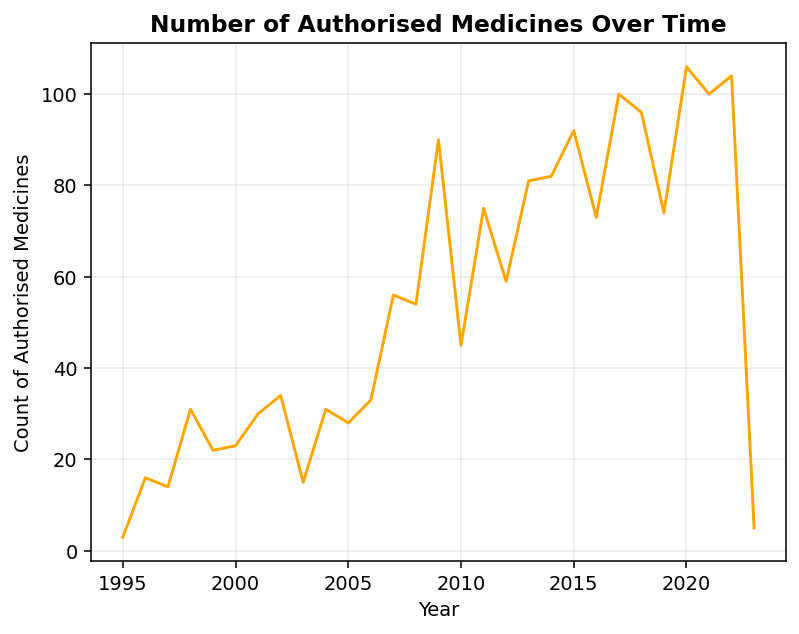

In [175]:
##### Check out drugs authorized drugs trend overtime #####
# Authorised medicines only
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

# Year of authorisation
authorised_df["authorised_year"] = authorised_df["marketing_authorisation_date"].dt.year

# Count per year (drop NaN years)
authorised_per_year = authorised_df["authorised_year"].dropna().value_counts().sort_index()

plt.figure()
authorised_per_year.plot(kind="line", color='orange')
plt.title("Number of Authorised Medicines Over Time")
plt.xlabel("Year")
plt.ylabel("Count of Authorised Medicines")
plt.show()

### **Top companies with most authorised medicines**

Viewing list of top 10 companies with the most authorized medicines.

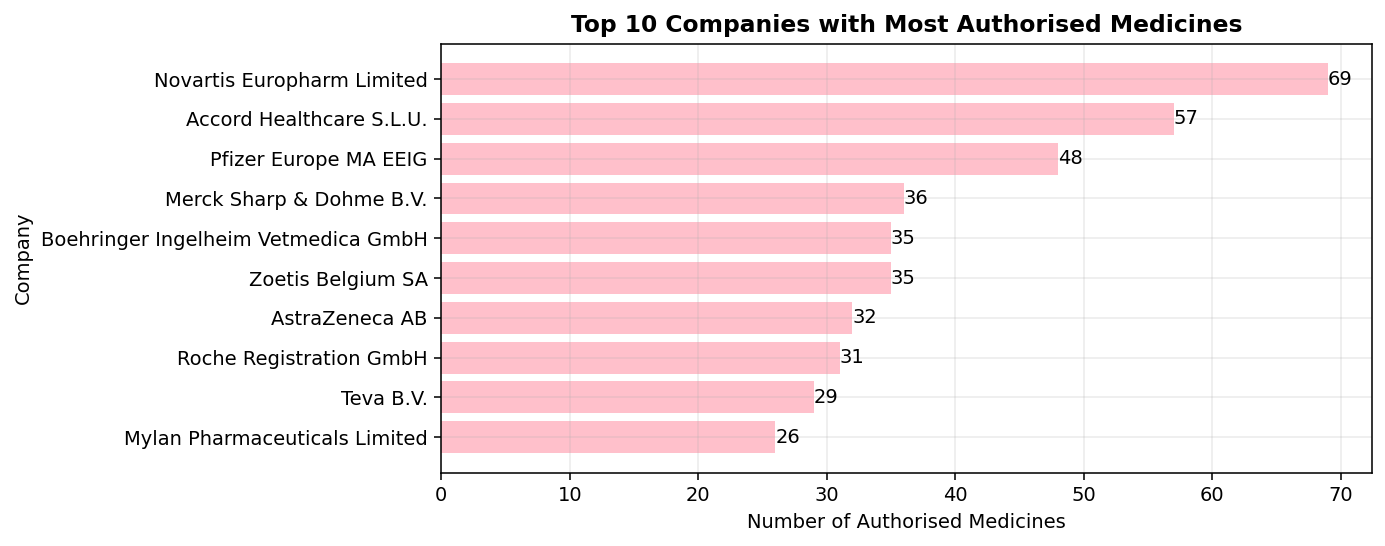

In [176]:
##### Check out companies with the most authorized medicines #####
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

company_counts = (
authorised_df["marketing_authorisation_holder_company_name"]
.value_counts()
.head(10)
.sort_values() # sort for barh readability
)

plt.figure(figsize=(10, 4))
plt.barh(company_counts.index, company_counts.values, color='pink')

# Add number on each bar for better readability
for i, v in enumerate(company_counts):
  plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Company")
plt.title("Top 10 Companies with Most Authorised Medicines")
plt.tight_layout()
plt.show()

### **Top therapeutic areas by authorised medicines**

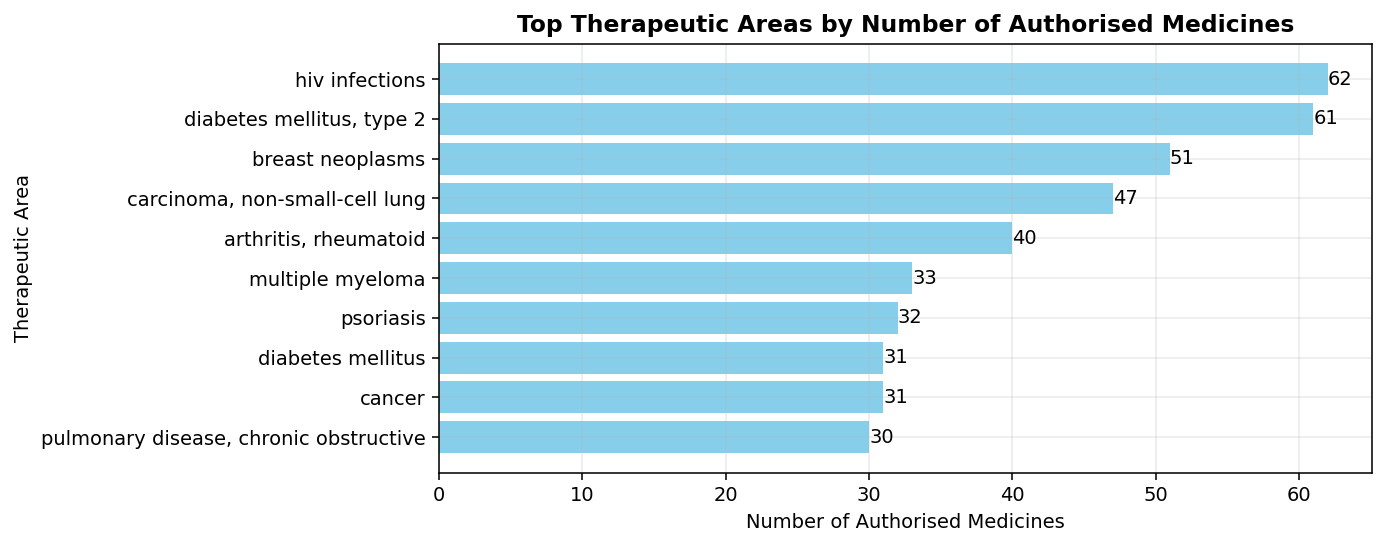

In [177]:
# Filter to get only authorized medicines
authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()

therapeutic_counts = (
authorised_df.explode("therapeutic_area_list")["therapeutic_area_list"]
.dropna()
.value_counts()
.head(10)
.sort_values()
)

# Plot bar graph
plt.figure(figsize=(10, 4))
plt.barh(therapeutic_counts.index, therapeutic_counts.values, color='skyblue')

# Add number on each bar for better readability
for i, v in enumerate(therapeutic_counts.values):
    plt.text(v, i, str(v), va='center')

plt.xlabel("Number of Authorised Medicines")
plt.ylabel("Therapeutic Area")
plt.title("Top Therapeutic Areas by Number of Authorised Medicines")
plt.tight_layout()
plt.show()

### **Patterns of Special Approvals and Overlap**

builds on (1–3) by asking whether approvals are “standard” or concentrated in special regulatory pathways, and whether those pathways form natural profiles for segmentation.


Special-pathway flag prevalence (share of medicines):
additional_monitoring        19.47%
orphan_medicine               8.15%
accelerated_assessment        2.41%
conditional_approval          2.41%
exceptional_circumstances     2.41%
dtype: object

Distribution of special_pathway_count:
special_pathway_count
0    1500
1     338
2      96
3      53
4       1
Name: count, dtype: int64

Most common pathway profiles:
pathway_profile
none                                                                 1500
additional_monitoring                                                 251
orphan_medicine                                                        50
orphan_medicine+additional_monitoring                                  50
orphan_medicine+conditional_approval+additional_monitoring             26
accelerated_assessment                                                 24
orphan_medicine+exceptional_circumstances+additional_monitoring        18
conditional_approval+additional_monitoring       

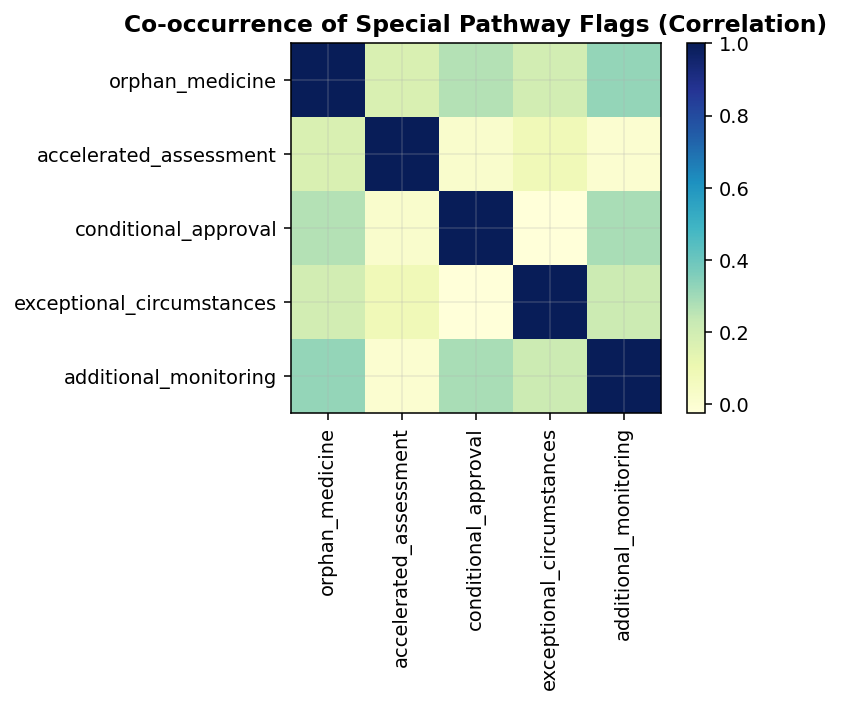

In [178]:

pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

# How common is each special pathway flag?
flag_rates = drugs_df[pathway_cols].mean().sort_values(ascending=False)
print("Special-pathway flag prevalence (share of medicines):")
print((flag_rates * 100).round(2).astype(str) + "%")

# How many special flags per medicine?
print("\nDistribution of special_pathway_count:")
print(drugs_df["special_pathway_count"].value_counts().sort_index())

# Most common pathway combinations
print("\nMost common pathway profiles:")
print(drugs_df["pathway_profile"].value_counts().head(15))

# Co-occurrence (do flags tend to appear together?)
corr = drugs_df[pathway_cols].astype(int).corr()

plt.figure(figsize=(6, 5))
plt.imshow(corr, interpolation="nearest", cmap="YlGnBu")
plt.xticks(range(len(pathway_cols)), pathway_cols, rotation=90)
plt.yticks(range(len(pathway_cols)), pathway_cols)
plt.title("Co-occurrence of Special Pathway Flags (Correlation)")
plt.colorbar()
plt.tight_layout()
plt.show()

### **Special approvals look different across categories and species**

It compares the regulatory “signal” across human vs veterinary, then zooming into veterinary species segmentation.


Special-pathway flag rates by category (mean of boolean flags):
                orphan_medicine  accelerated_assessment  conditional_approval  \
category_clean                                                                  
human                     0.095                   0.023                 0.028   
veterinary                0.000                   0.028                 0.000   

                exceptional_circumstances  additional_monitoring  
category_clean                                                    
human                               0.026                  0.227  
veterinary                          0.011                  0.000  


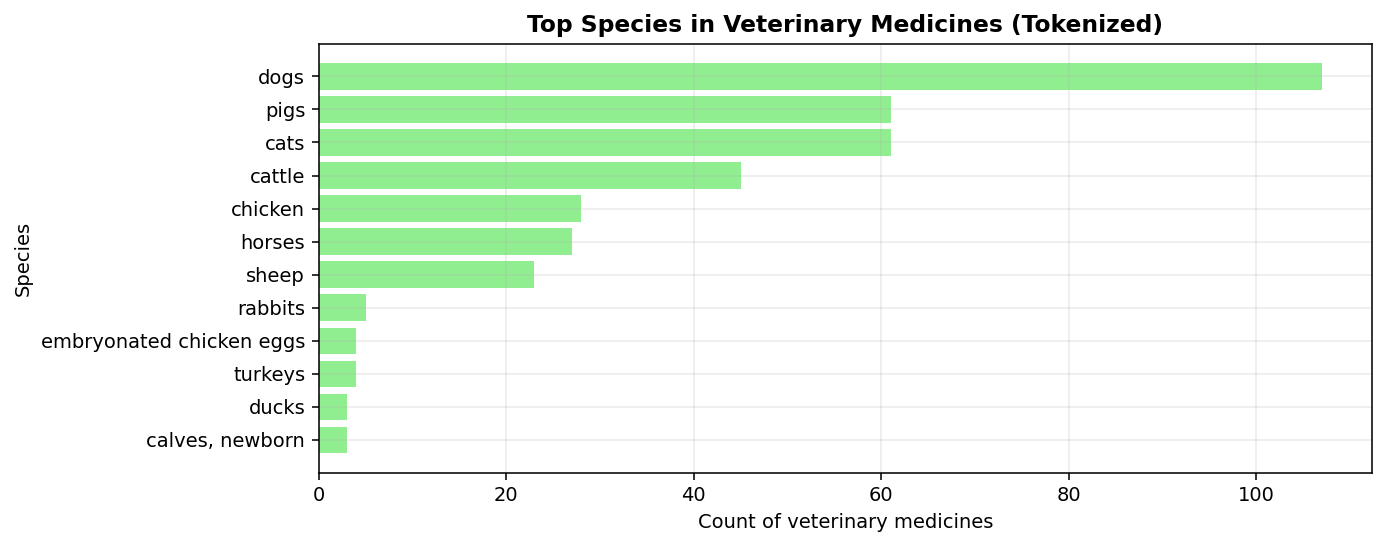


Share of veterinary medicines that target multiple species:
0.277


In [179]:

import matplotlib.pyplot as plt

pathway_cols = [
    "orphan_medicine",
    "accelerated_assessment",
    "conditional_approval",
    "exceptional_circumstances",
    "additional_monitoring",
]

# Compare special-pathway rates across human vs veterinary
print("Special-pathway flag rates by category (mean of boolean flags):")
print(drugs_df.groupby("category_clean")[pathway_cols].mean().round(3))

# Veterinary-only: species distribution (tokenized list)
vet_df = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

species_counts = (
    vet_df.explode("species_list")["species_list"]
    .dropna()
    .value_counts()
    .head(12)
    .sort_values()
)

plt.figure(figsize=(10, 4))
plt.barh(species_counts.index, species_counts.values, color="lightgreen")
plt.xlabel("Count of veterinary medicines")
plt.ylabel("Species")
plt.title("Top Species in Veterinary Medicines (Tokenized)")
plt.tight_layout()
plt.show()

# Multi-species structure (useful segmentation signal)
print("\nShare of veterinary medicines that target multiple species:")
print(vet_df["multi_species_flag"].mean().round(3))

### **Variability for NLP clustering**

Unstructured text that will power unsupervised discovery of disease/indication clusters.

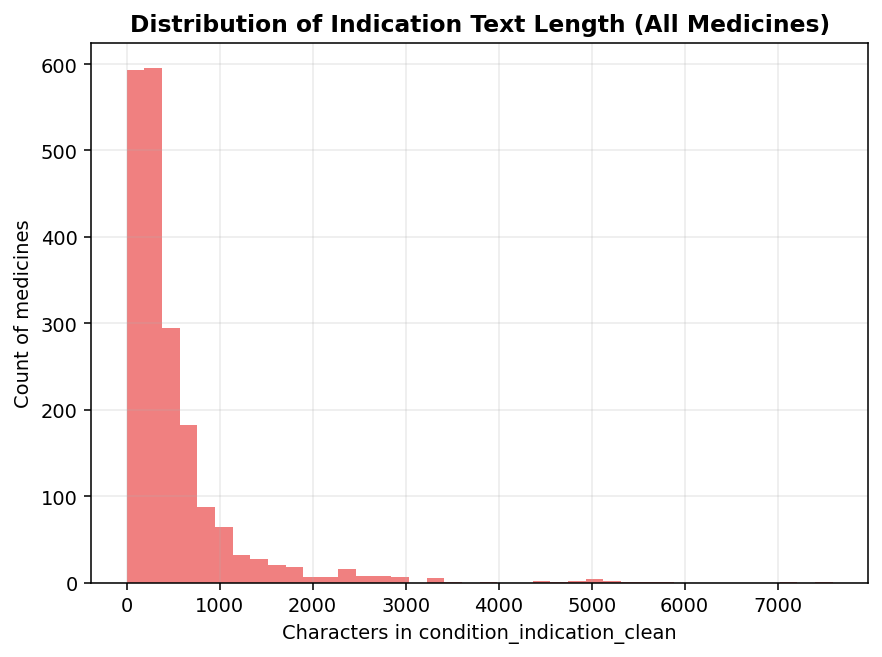


Indication length summary by category_clean:
                 count        mean    50%     max
category_clean                                   
human           1706.0  519.284877  299.5  7592.0
veterinary       282.0  431.574468  291.0  2513.0

Indication length summary by authorisation_status_clean:
                             count        mean    50%     max
authorisation_status_clean                                   
authorised                  1573.0  526.957406  311.0  7592.0
refused                       57.0  112.824561   40.0   971.0
unknown                        1.0    0.000000    0.0     0.0
withdrawn                    357.0  482.546218  301.0  4513.0

Top 25 words in authorised indication text:
[('with', 3636), ('and', 3403), ('the', 3314), ('for', 2839), ('treatment', 2527), ('patients', 2154), ('indicated', 2011), ('adult', 1088), ('who', 1018), ('combination', 956), ('have', 733), ('are', 603), ('therapy', 593), ('not', 572), ('adults', 541), ('years', 481), ('disea

In [180]:
from collections import Counter

# Distribution of text length
plt.figure()
plt.hist(drugs_df["indication_length"].dropna(), bins=40, color="lightcoral")
plt.title("Distribution of Indication Text Length (All Medicines)")
plt.xlabel("Characters in condition_indication_clean")
plt.ylabel("Count of medicines")
plt.tight_layout()
plt.show()

# Text length summaries by category and status
print("\nIndication length summary by category_clean:")
print(drugs_df.groupby("category_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

print("\nIndication length summary by authorisation_status_clean:")
print(drugs_df.groupby("authorisation_status_clean")["indication_length"].describe()[["count", "mean", "50%", "max"]])

# Lightweight top-words check (gives intuition about recurring themes)
def top_words(series, n=25, min_len=3):
    words = []
    for txt in series:
        tokens = str(txt).split()
        tokens = [t for t in tokens if len(t) >= min_len]
        words.extend(tokens)
    return Counter(words).most_common(n)

authorised_df = drugs_df[drugs_df["authorisation_status_clean"] == "authorised"].copy()
withdrawn_df = drugs_df[drugs_df["authorisation_status_clean"] == "withdrawn"].copy()

print("\nTop 25 words in authorised indication text:")
print(top_words(authorised_df["condition_indication_clean"], n=25))

print("\nTop 25 words in withdrawn indication text:")
print(top_words(withdrawn_df["condition_indication_clean"], n=25))

##**M2 Question 4 - Analysis**

How do special approvals differ between human and veterinary medicines? Within veterinary medicines, which species segments have unique combinations of regulatory flags?

In [181]:
#@title Veterinary Sparsity
vet = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

vet_flag_summary = pd.DataFrame({
    "vet_true_count": vet[pathway_cols].sum().astype(int),
    "vet_true_rate_%": (vet[pathway_cols].mean() * 100).round(2)
}).sort_values("vet_true_count", ascending=False)

vet_flag_summary


,vet_true_count,vet_true_rate_%
accelerated_assessment,8,2.84
exceptional_circumstances,3,1.06
orphan_medicine,0,0.00
conditional_approval,0,0.00
additional_monitoring,0,0.00


In [182]:
#@title Any special approval
print(f'The number of veterinary observations is: {len(vet)}\n')

any_special_vet = (vet["special_pathway_count"] > 0).sum()
total_vet = len(vet)

print(f"Vet with any special flag: {any_special_vet}/{total_vet} ({any_special_vet/total_vet:.2%})")

drugs_df["special_pathway_label"] = pd.cut(
    drugs_df["special_pathway_count"],
    bins=[-1, 0, 1, 2, 5],
    labels=["none", "one_flag", "two_flags", "3+_flags"]
)

vet["special_pathway_label"] = drugs_df.loc[vet.index, "special_pathway_label"]
vet["special_pathway_label"].value_counts()


The number of veterinary observations is: 282

Vet with any special flag: 8/282 (2.84%)


,count
special_pathway_label,
none,274
one_flag,5
two_flags,3
3+_flags,0


In [183]:
#@title Density of Veterinary flags
true_cells = int(vet[pathway_cols].sum().sum())
total_cells = int(len(vet) * len(pathway_cols))
density = true_cells / total_cells if total_cells else np.nan

print(f"Veterinary flag density: {density:.4%} (True cells / all vet×flag cells)")


Veterinary flag density: 0.7801% (True cells / all vet×flag cells)


In [184]:
#@title Human vs Veterinary prevalence per flag
# counts and rates by category
by_cat_counts = drugs_df.groupby("category_clean")[pathway_cols].sum().astype(int)

by_cat_rates = (drugs_df.groupby("category_clean")[pathway_cols].mean() * 100).round(2)

summary = (
    pd.concat(
        [
            by_cat_counts.add_suffix("_true_count"),
            by_cat_rates.add_suffix("_true_rate_%")
        ],
        axis=1
    )
)

# reshape into a flag-by-flag table for human vs vet
rows = []
for f in pathway_cols:
    h_true = summary.loc["human", f"{f}_true_count"]
    v_true = summary.loc["veterinary", f"{f}_true_count"]
    h_rate = summary.loc["human", f"{f}_true_rate_%"]
    v_rate = summary.loc["veterinary", f"{f}_true_rate_%"]
    rows.append({
        "flag": f,
        "human_true": int(h_true),
        "human_rate_%": float(h_rate),
        "vet_true": int(v_true),
        "vet_rate_%": float(v_rate),
        "rate_diff_pp": float(h_rate - v_rate)   # percentage points
    })

flag_prevalence = pd.DataFrame(rows).sort_values("rate_diff_pp", ascending=False)
flag_prevalence


,flag,human_true,human_rate_%,vet_true,vet_rate_%,rate_diff_pp
4,additional_monitoring,387,22.68,0,0.00,22.68
0,orphan_medicine,162,9.50,0,0.00,9.50
2,conditional_approval,48,2.81,0,0.00,2.81
3,exceptional_circumstances,45,2.64,3,1.06,1.58
1,accelerated_assessment,40,2.34,8,2.84,-0.50


**Human vs Veterinary: Special-approval flag prevalence**

To understand how special approvals differ between human and veterinary medicines, I computed the prevalence of each “special pathway” flag by category (count of True and % of medicines with True). The results show a strong concentration of special-approval flags in human medicines, with near-zero presence in veterinary medicines:

Additional monitoring appears in 22.68% of human medicines (387/1706) but 0% of veterinary medicines (0/282), a +22.68 percentage-point gap.

Orphan medicine is present in 9.50% of human medicines (162/1706) and 0% of veterinary medicines, a +9.50 pp gap.

Conditional approval appears in 2.81% of human medicines (48/1706) and 0% of veterinary medicines, a +2.81 pp gap.

Exceptional circumstances exists in both categories but remains higher in humans (2.64%) than veterinary (1.06%), a +1.58 pp gap.

The only flag where veterinary is slightly higher is accelerated assessment (human 2.34% vs veterinary 2.84%), a difference of −0.50 pp.

Overall, these prevalence patterns indicate that most special-approval pathways are effectively absent in the veterinary subset, and even the flags that do exist in veterinary occur in very small absolute numbers (e.g., only 8 accelerated-assessment veterinary medicines and 3 exceptional-circumstances veterinary medicines).

**Analytical issue for the project question**

This concentration creates a core challenge for the second part of the business question (“Within veterinary medicines, which species segments have unique combinations of regulatory flags?”). Because veterinary medicines have extremely few positive cases, there is limited variation to learn from:

Most veterinary medicines have no special-approval flags at all (special_pathway_count = 0 dominates).

Several flags are structural zeros in veterinary (orphan, conditional approval, additional monitoring), meaning they provide no signal for segmentation or pattern discovery within veterinary.

With only a handful of positive veterinary cases spread across two flags, any species-level differences are likely to be unstable (small-N effects), and many unsupervised methods (e.g., clustering on these five binary flags) will collapse into a single “none” cluster with a few outliers.

As a result, the human vs veterinary comparison is informative and interpretable, but the veterinary-only segmentation based solely on these special-approval flags may be weakly identifiable or only support outlier-level insights (e.g., which specific products carry accelerated assessment or exceptional circumstances), rather than robust species “segments.”

**From prevalence to Inference**

Even though the prevalence table already shows large differences between human and veterinary medicines, I still run an inference test to answer a specific question: are these differences likely to reflect a real association between “category” (human vs veterinary) and each special-approval flag, rather than random variation in a finite sample? This step is especially important here because the veterinary subset is much smaller (282 vs 1706), and several veterinary flags occur rarely or not at all. In other words, the descriptive gaps are clear, but the inference step helps formalize whether the observed differences are statistically compatible with “no association”.

**Association Rule Metrics**

Because our variables are binary regulatory indicators, association-rule metrics (support, confidence, lift) are applicable and provide descriptive measures of co-occurrence; however, due to extreme sparsity in veterinary flags, rule mining within veterinary using only these five indicators is likely to produce trivial or unstable patterns, so it is more informative on the human subset.

In [185]:
#@title Chi Square & Fisher Test
from scipy.stats import chi2_contingency, fisher_exact

In [186]:
# Chi Square
def make_2x2(flag):
    obs = np.array([
        [
            int(((drugs_df["category_clean"]=="human") & (drugs_df[flag]==True)).sum()),
            int(((drugs_df["category_clean"]=="human") & (drugs_df[flag]==False)).sum())
        ],
        [
            int(((drugs_df["category_clean"]=="veterinary") & (drugs_df[flag]==True)).sum()),
            int(((drugs_df["category_clean"]=="veterinary") & (drugs_df[flag]==False)).sum())
        ]
    ])
    return obs

checks = []
for f in pathway_cols:
    obs = make_2x2(f)
    chi2, p, dof, exp = chi2_contingency(obs, correction=False)
    checks.append({
        "flag": f,
        "observed": obs.tolist(),
        "expected": np.round(exp, 2).tolist(),
        "min_expected": float(exp.min()),
        "n_expected_lt_5": int((exp < 5).sum()),
        "vet_true": int(obs[1,0])
    })

assumption_df = pd.DataFrame(checks).sort_values("min_expected")
assumption_df



,flag,observed,expected,min_expected,n_expected_lt_5,vet_true
1,accelerated_assessment,"[[40, 1666], [8, 274]]","[[41.19, 1664.81], [6.81, 275.19]]",6.808853,0,8
2,conditional_approval,"[[48, 1658], [0, 282]]","[[41.19, 1664.81], [6.81, 275.19]]",6.808853,0,0
3,exceptional_circumstances,"[[45, 1661], [3, 279]]","[[41.19, 1664.81], [6.81, 275.19]]",6.808853,0,3
0,orphan_medicine,"[[162, 1544], [0, 282]]","[[139.02, 1566.98], [22.98, 259.02]]",22.979879,0,0
4,additional_monitoring,"[[387, 1319], [0, 282]]","[[332.1, 1373.9], [54.9, 227.1]]",54.896378,0,0


**Decision trail: chi-square vs Fisher**

For each flag, I constructed a 2×2 contingency table (human/veterinary × True/False). I computed the chi-square expected counts to evaluate whether the usual chi-square approximation guideline holds. In this dataset, all minimum expected counts were ≥ 6.81 and no expected cells were below 5 (n_expected_lt_5 = 0), so a chi-square test of independence would be acceptable under the common rule.

However, veterinary positives are extremely sparse (including several flags with 0 veterinary True cases and others with single-digit counts). Since each comparison is a 2×2 table and the data are sparse and imbalanced, I use Fisher’s exact test as the primary inferential method because it provides an exact p-value that does not rely on large-sample approximations.

For transparency, I report chi-square p-values as a sensitivity check; if both methods agree, it strengthens confidence that conclusions are not sensitive to the choice of test.

In [187]:
# Fisher
results = []
for f in pathway_cols:
    obs = make_2x2(f)

    # Fisher (two-sided)
    OR, p_fisher = fisher_exact(obs, alternative="two-sided")

    # Chi-square (uncorrected + Yates corrected)
    chi2, p_chi, dof, exp = chi2_contingency(obs, correction=False)
    chi2_y, p_chi_y, dof_y, exp_y = chi2_contingency(obs, correction=True)

    results.append({
        "flag": f,
        "observed_table": obs.tolist(),
        "min_expected": float(exp.min()),
        "fisher_p": p_fisher,
        "chi_p": p_chi,
        "chi_p_yates": p_chi_y, # Yates correction is a math filter to make Chi test more conservative when small numbers
        "fisher_OR": OR
    })

test_results = pd.DataFrame(results).sort_values("fisher_p")
test_results


,flag,observed_table,min_expected,fisher_p,chi_p,chi_p_yates,fisher_OR
4,additional_monitoring,"[[387, 1319], [0, 282]]",54.896378,2.705223e-29,4.986219e-19,1.033777e-18,inf
0,orphan_medicine,"[[162, 1544], [0, 282]]",22.979879,1.055087e-11,6.684168e-08,1.277966e-07,inf
2,conditional_approval,"[[48, 1658], [0, 282]]",6.808853,1.134761e-03,4.352283e-03,8.240825e-03,inf
3,exceptional_circumstances,"[[45, 1661], [3, 279]]",6.808853,1.411080e-01,1.106937e-01,1.658412e-01,2.519567
1,accelerated_assessment,"[[40, 1666], [8, 274]]",6.808853,6.737490e-01,6.178977e-01,7.722443e-01,0.822329


Our analysis shows that the differences between human and veterinary medicines aren't just random—they follow a clear pattern. Three specific labels—additional monitoring, orphan medicine, and conditional approval—are very common in human drugs but completely absent in veterinary ones. The math confirms this is a strong, intentional gap, not just a coincidence.

On the other hand, for exceptional circumstances and accelerated assessment, human and veterinary drugs are treated very similarly. There is no statistically meaningful difference between the two groups here.

What this means for our project: Because veterinary drugs almost never use these "special approval" labels, we can't use these five flags alone to group or categorize veterinary medicines. There simply isn't enough variety in the data. To move forward with the veterinary side of the study, we should either:

Look closely at the few rare "positive" cases we did find.

Add more data points (different types of labels) to help us see a more complete picture of how veterinary drugs are regulated.

In [188]:
bool_cols = boolean_cols  # reuse your list
vet = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

vet_bool_summary = pd.DataFrame({
    "vet_true_count": vet[bool_cols].sum().astype(int),
    "vet_true_rate_%": (vet[bool_cols].mean() * 100).round(2),
}).sort_values("vet_true_count", ascending=False)

vet_bool_summary


,vet_true_count,vet_true_rate_%
generic,25,8.87
accelerated_assessment,8,2.84
exceptional_circumstances,3,1.06
patient_safety,0,0.00
biosimilar,0,0.00
additional_monitoring,0,0.00
conditional_approval,0,0.00
orphan_medicine,0,0.00


In [189]:
#@title Veterinary Informative boolean features
vet = drugs_df[drugs_df["category_clean"]=="veterinary"].copy()

# Start from boolean_cols plus status flags
base_binary = boolean_cols + ["is_authorised", "is_withdrawn", "is_refused"]

# Keep only features that are not constant in veterinary (0 < mean < 1)
binary_means = vet[base_binary].mean()
binary_keep = binary_means[(binary_means > 0) & (binary_means < 1)].index.tolist()

binary_keep, binary_means.sort_values()


(['generic',
  'exceptional_circumstances',
  'accelerated_assessment',
  'is_authorised',
  'is_withdrawn',
  'is_refused'],
 patient_safety               0.000000
 additional_monitoring        0.000000
 biosimilar                   0.000000
 conditional_approval         0.000000
 orphan_medicine              0.000000
 exceptional_circumstances    0.010638
 is_refused                   0.014184
 accelerated_assessment       0.028369
 generic                      0.088652
 is_withdrawn                 0.163121
 is_authorised                0.822695
 dtype: float64)

Within veterinary medicines, several regulatory flags are structurally zero and provide no segmentation signal. After removing constant features, the veterinary subset retains six binary indicators with variation (generic, accelerated assessment, exceptional circumstances, and authorization status flags). Because this binary space is still small, the next step is to expand feature representation using structured categorical and list-text fields (ATC and pharmacotherapeutic group), while keeping species out of the feature set to avoid leakage.

**Expand Vet Features to ATC codes & Pharmacotherapeutic Groups**

In [190]:
#@title Veterinary only feature matrix
vet = drugs_df[drugs_df["category_clean"] == "veterinary"].copy()

needed = binary_keep + ["pharm_group_list", "atc_level1", "atc_level2"]
missing = [c for c in needed if c not in vet.columns]

print("Vet rows:", len(vet))
print("Missing required columns:", missing)

vet[needed].head(3)

Vet rows: 282
Missing required columns: []


,generic,exceptional_circumstances,accelerated_assessment,is_authorised,is_withdrawn,is_refused,pharm_group_list,atc_level1,atc_level2
662,False,False,False,0,1,0,"[permethrin, combinations, ectoparasiticides f...",Q,QP5
666,False,False,False,0,1,0,[immunologicals for aves],Q,QI0
812,False,False,False,0,1,0,"[inactivated viral vaccines, bluetongue virus,...",Q,QI0


In [191]:
#@title Pharmacotherapeutic Groups (From multi-Label to Multi-Hot)
from sklearn.preprocessing import MultiLabelBinarizer

# Frequency of each pharm group label within vet
pg_counts = pd.Series([i for sub in vet["pharm_group_list"] for i in sub]).value_counts()
print(pg_counts.head(15))

min_count = 5
keep_pg = set(pg_counts[pg_counts >= min_count].index)
print("Labels kept (>= min_count):", len(keep_pg))

pg_filtered = vet["pharm_group_list"].apply(lambda lst: [x for x in lst if x in keep_pg])

mlb = MultiLabelBinarizer()
pg_X = pd.DataFrame(
    mlb.fit_transform(pg_filtered),
    columns=[f"pg__{c}" for c in mlb.classes_],
    index=vet.index
)

pg_X.shape


immunologicals                                                 23
antibacterials for systemic use                                13
immunologicals for suidae                                      11
immunologicals for felidae,                                     9
immunologicals for aves                                         9
oxicams                                                         8
anti-inflammatory and anti-rheumatic products, non-steroids     6
ectoparasiticides for topical use, incl. insecticides           6
antiparasitic products, insecticides and repellents             5
immunologicals for bovidae                                      4
immunologicals for equidae                                      4
musculo-skeletal system                                         4
inactivated viral vaccines                                      3
corticosteroids, dermatological preparations                    3
immunologicals for canidae                                      3
Name: coun

(282, 9)

To ensure the clustering algorithm identifies meaningful patterns rather than getting lost in the "noise" of rare data, we processed the pharmacotherapeutic groups using a multi-hot encoding strategy. Since a single veterinary medicine can belong to multiple therapeutic categories, we converted the original list into nine distinct binary features. To maintain statistical significance, we applied a frequency threshold (min_count=5), focusing only on categories that appear in five or more products. This filter removes extremely rare labels while highlighting common, structural categories—such as "immunologicals", providing the model with the consistent data it needs to group similar medicines effectively.

In [192]:
#@title ATC codes
atc1_X = pd.get_dummies(vet["atc_level1"].fillna("missing"), prefix="atc1")
atc2_X = pd.get_dummies(vet["atc_level2"].fillna("missing"), prefix="atc2")

atc1_X.shape, atc2_X.shape


((282, 3), (282, 21))

atc1_x has three categorical columns (Broad class - Anatomical/Pharmacological group)

atc2_x has twenty-one categorical columns (Specific Class - therapeutic/pharmacological subgroup)

In [193]:
X_bin = pd.concat(
    [
        vet[binary_keep].astype(int),
        pg_X.astype(int),
        atc1_X.astype(int),
        atc2_X.astype(int),
    ],
    axis=1
)

print("X_bin shape:", X_bin.shape)

active_per_row = X_bin.sum(axis=1)
print(active_per_row.describe())
active_per_row.value_counts().head(10)


X_bin shape: (282, 39)
count    282.000000
mean       3.446809
std        0.658106
min        3.000000
25%        3.000000
50%        3.000000
75%        4.000000
max        6.000000
dtype: float64


,count
3,179
4,83
5,17
6,3


On average, each veterinary medicine has about 3 to 4 active features.

Most veterinary medicines match only a few of our feature categories (ATC group + pharmacotherapeutic group), not dozens.

Most medicines are pretty similar in how many features they have — they’re usually close to 3 or 4. Only a few medicines have noticeably more (like 5 or 6).

Most veterinary medicines are described by exactly 3–4 active indicators in our current feature design. A small number have richer profiles (5–6), usually because they fall into multiple pharmacotherapeutic-group labels or carry extra binary flags like ‘generic’ or ‘withdrawn’.

In [194]:
import matplotlib.pyplot as plt

# Pastel-ish defaults
plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25
plt.rcParams["axes.titleweight"] = "bold"

PASTELS = ["#AEC6CF","#FFB347","#B39EB5","#77DD77","#F49AC2",
           "#CFCFC4","#FFD1DC","#C9C9FF","#FDFD96","#B0E0E6"]

##**Market Basket Analysis**



**Apriori on X_Bin**

In [200]:
#@title Frequent itemsets
!pip -q install mlxtend

from mlxtend.frequent_patterns import apriori, association_rules

# Frequent itemsets
freq = apriori(X_bin.astype(bool), min_support=0.02, use_colnames=True)
freq["itemset_size"] = freq["itemsets"].apply(len)

# Rules (lift is the key metric to avoid “confidence traps”)
rules = association_rules(freq, metric="lift", min_threshold=1.0)

# Add helper columns for plotting
rules["antecedent_len"] = rules["antecedents"].apply(len)
rules["consequent_len"] = rules["consequents"].apply(len)
rules["rule"] = rules.apply(lambda r: f"{list(r['antecedents'])} → {list(r['consequents'])}", axis=1)

rules.shape, freq.shape


((364, 17), (111, 3))

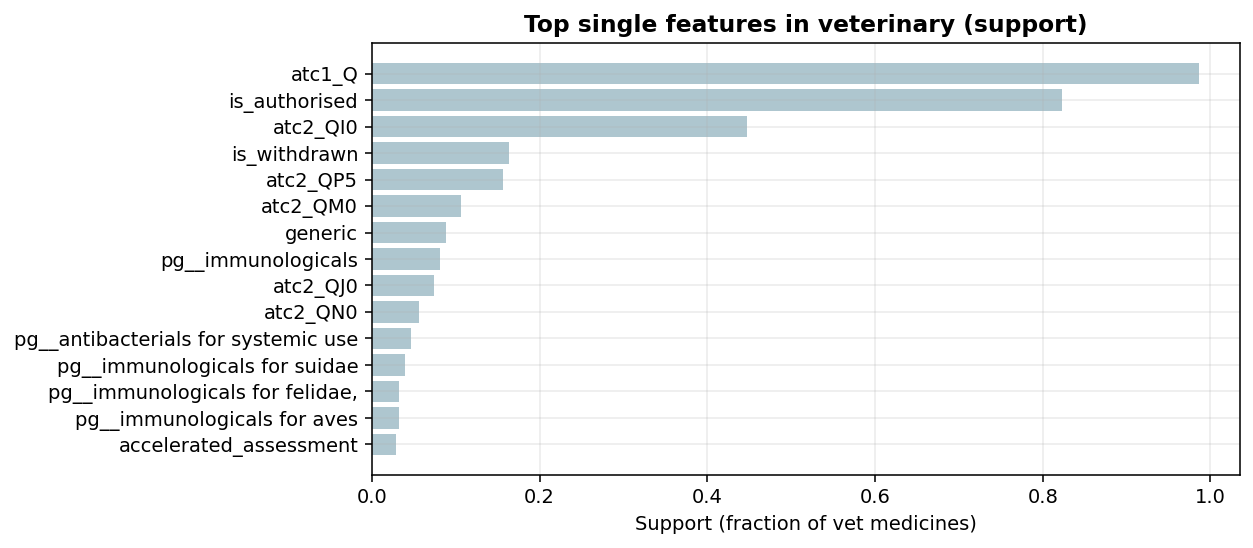

In [201]:
top1 = (freq[freq["itemset_size"]==1]
        .sort_values("support", ascending=False)
        .head(15)
        .copy())
top1["label"] = top1["itemsets"].apply(lambda s: list(s)[0])

plt.figure(figsize=(8,4))
plt.barh(top1["label"][::-1], top1["support"][::-1], color=PASTELS[0])
plt.title("Top single features in veterinary (support)")
plt.xlabel("Support (fraction of vet medicines)")
plt.show()


An analysis of item frequency, or "support", within the dataset reveals that the most prevalent features are primarily structural rather than behavioral. For instance, the nearly universal presence of the ATC level 1 = Q designation is a baseline coding convention for veterinary medicines rather than a unique discovery. Similarly, the high frequency of authorized status (approximately 82%) reflects the nature of the regulatory environment rather than a specific market segment. The genuine analytical "signal" resides in features with mid-range support, such as specific ATC levels (e.g., QI0, QP5, QM0) and indicators like generic or withdrawn status. While pharmaceutical groups such as immunologicals and systemic antibacterials appear less frequently, they provide the necessary variation required to differentiate clusters effectively, whereas the nearly constant features serve more as a contextual background.

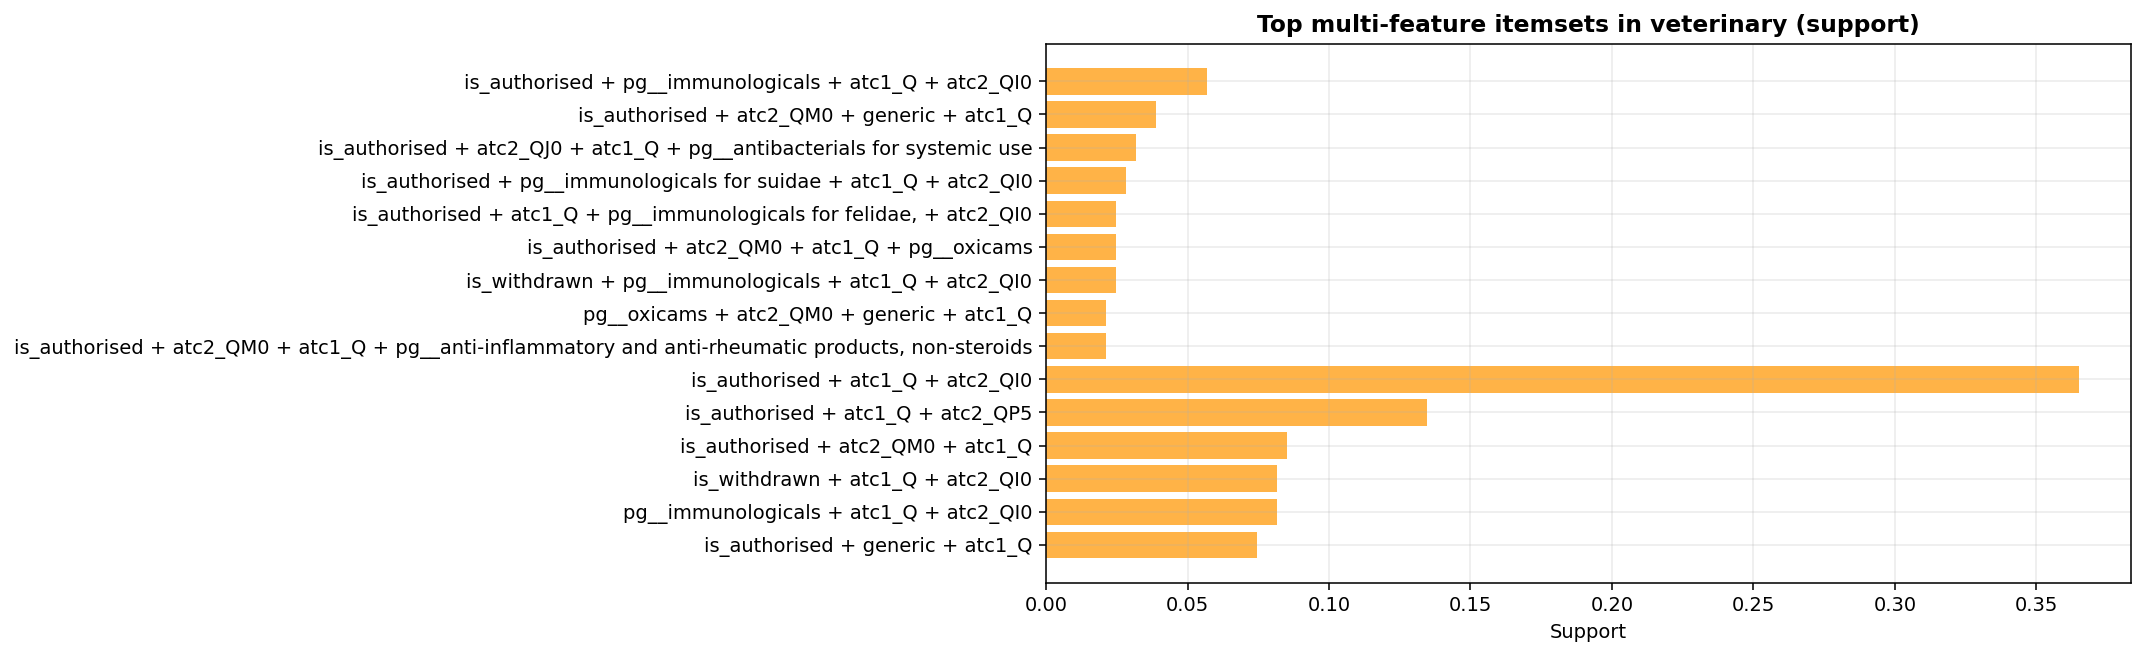

In [202]:
topk = (freq[freq["itemset_size"]>=2]
        .sort_values(["itemset_size","support"], ascending=[False, False])
        .head(15)
        .copy())
topk["label"] = topk["itemsets"].apply(lambda s: " + ".join(list(s)))

plt.figure(figsize=(10,5))
plt.barh(topk["label"][::-1], topk["support"][::-1], color=PASTELS[1])
plt.title("Top multi-feature itemsets in veterinary (support)")
plt.xlabel("Support")
plt.show()


The analysis of frequent itemsets—which identifies the combinations that appear most often—is heavily influenced by the high baseline frequency of certain structural variables. For example, the most prevalent combination often includes is_authorised, atc2_QI0, and atc1_Q. This occurrence is driven by the mathematical fact that "near-universal" items (like the Q designation) and "highly common" items (like authorization status) will naturally pair with the larger therapeutic groups. Consequently, many of the top-ranking itemsets reflect these pervasive, "always-on" features rather than rare or specific clinical patterns. Identifying these dominant combinations is crucial, as they can sometimes obscure the more nuanced, informative signals that are vital for meaningful market segmentation.

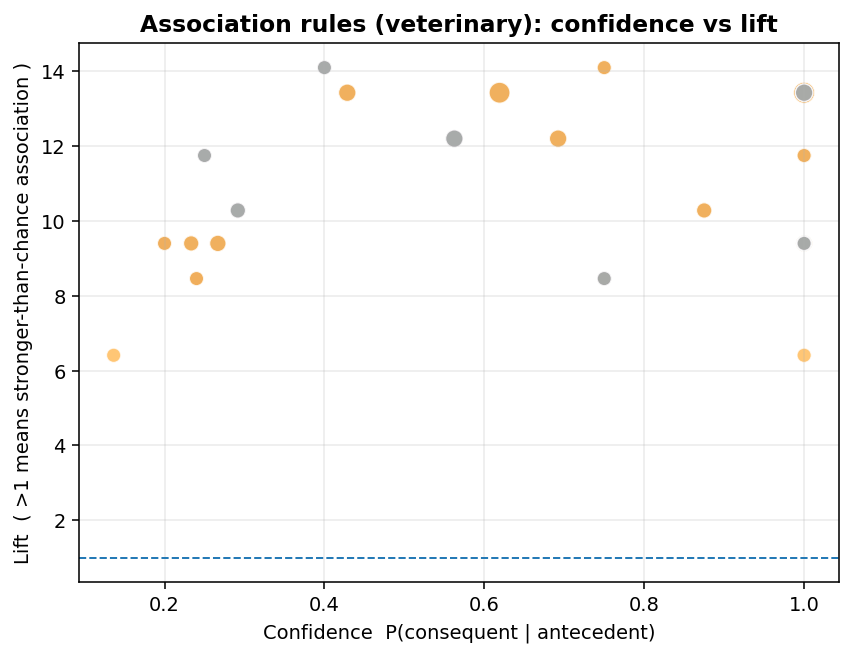

In [203]:
# keep only a reasonable number of rules for a readable plot
plot_rules = rules.sort_values(["lift","support"], ascending=False).head(80).copy()

plt.figure(figsize=(7,5))
plt.scatter(
    plot_rules["confidence"],
    plot_rules["lift"],
    s=(plot_rules["support"]*2500).clip(30, 400),
    c=[PASTELS[min(i, len(PASTELS)-1)] for i in plot_rules["antecedent_len"]],
    alpha=0.75,
    edgecolors="white",
    linewidths=0.6
)

plt.axhline(1.0, linestyle="--", linewidth=1)
plt.title("Association rules (veterinary): confidence vs lift")
plt.xlabel("Confidence  P(consequent | antecedent)")
plt.ylabel("Lift  ( >1 means stronger-than-chance association )")
plt.show()


In this visualization, Confidence represents the reliability of a rule (how often the consequence occurs given the antecedent), while Lift measures the strength of that association compared to random chance. The presence of numerous points with exceptionally high Lift—ranging from 8 to 14—indicates that certain rare categories become significantly more predictable when specific precursors are present. This pattern highlights a strong classification consistency within the data; specifically, it demonstrates that ATC2 codes and pharmacotherapeutic labels are not independent, but rather highly aligned. Ultimately, these rules capture the inherent logical mapping between different medical classification systems and the relationship between a product's status and its generic categorization.

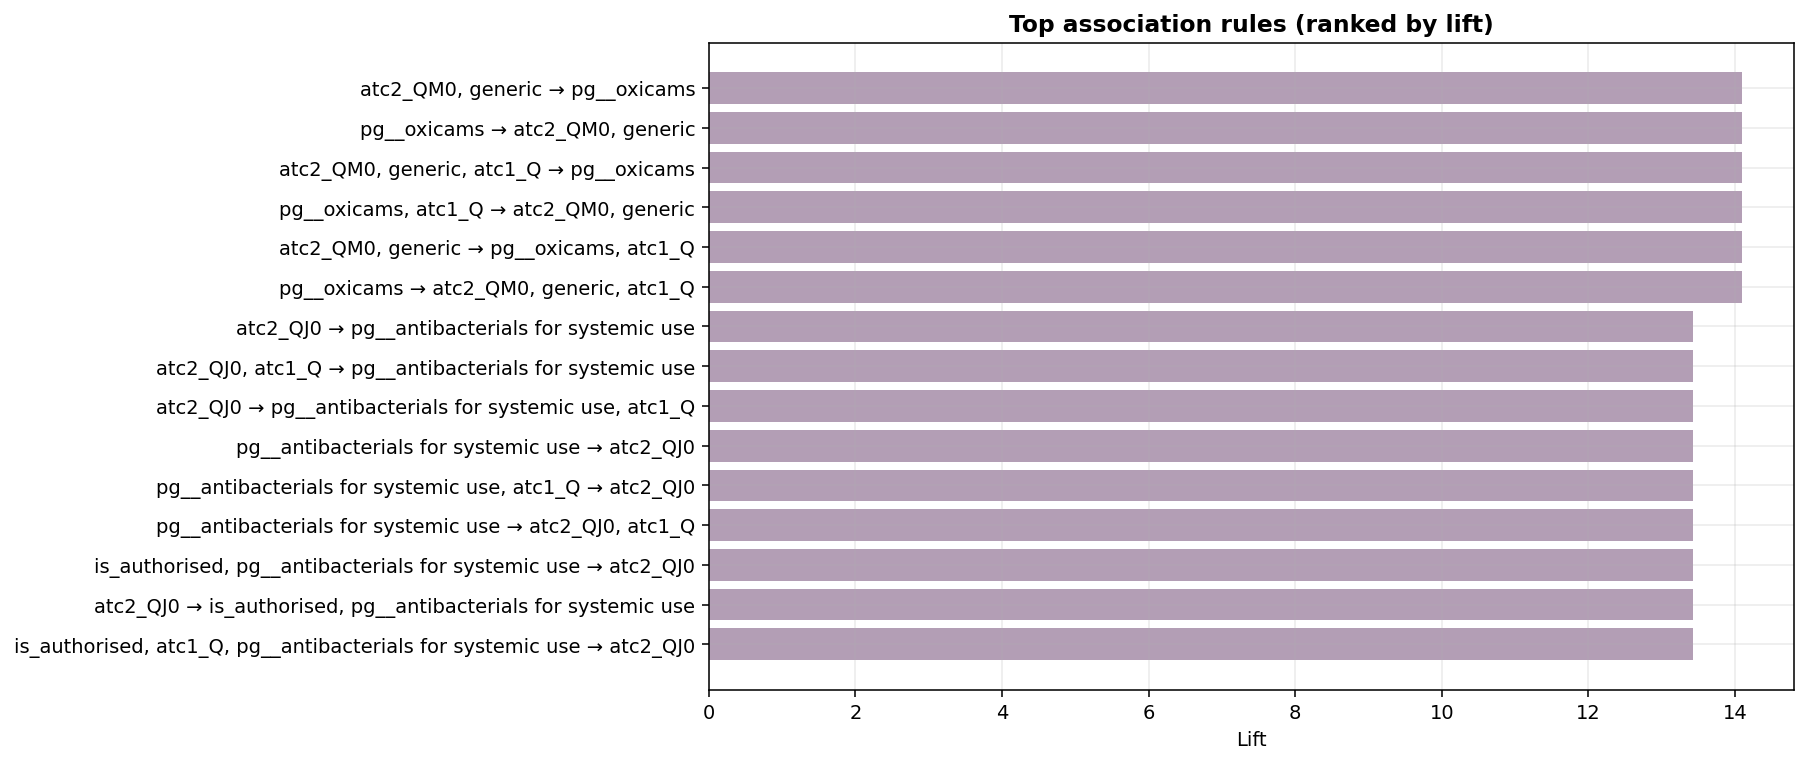

In [204]:
# Take top rules by lift (filter out trivial 1→1 rules if you want)
top_rules = (rules
             .sort_values(["lift","support"], ascending=False)
             .head(15)
             .copy())

top_rules["rule_str"] = top_rules.apply(
    lambda r: f"{', '.join(list(r['antecedents']))} → {', '.join(list(r['consequents']))}",
    axis=1
)

plt.figure(figsize=(10,6))
plt.barh(top_rules["rule_str"][::-1], top_rules["lift"][::-1], color=PASTELS[2])
plt.title("Top association rules (ranked by lift)")
plt.xlabel("Lift")
plt.show()


Because some features are near-universal in the veterinary subset (e.g., atc1_Q) or very common (e.g., is_authorised), they frequently appear in high-support itemsets and can make some “top itemsets” look obvious. This does not invalidate the market basket analysis; it simply means that the most frequent itemsets partly reflect baseline structure of the dataset. The more decision-relevant insights come from rules/itemsets where the association strength (lift) is high and the items are specific (e.g., ATC2 + pharmacotherapeutic group + status/generic), rather than from combinations dominated by near-constant items.

##**Clustering**

In [205]:
from sklearn.metrics import pairwise_distances

X = X_bin.astype(int).to_numpy()   # <-- force numpy array

D_full = pairwise_distances(X, metric="jaccard")

print("Distance matrix shape:", D_full.shape)
print("Diagonal all zeros:", np.allclose(np.diag(D_full), 0))

# summarize distances (exclude diagonal)
mask = ~np.eye(D_full.shape[0], dtype=bool)
vals = D_full[mask]

print(pd.Series(vals).describe())



Distance matrix shape: (282, 282)
Diagonal all zeros: True
count    79242.000000
mean         0.566274
std          0.229727
min          0.000000
25%          0.500000
50%          0.600000
75%          0.714286
max          1.000000
dtype: float64


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


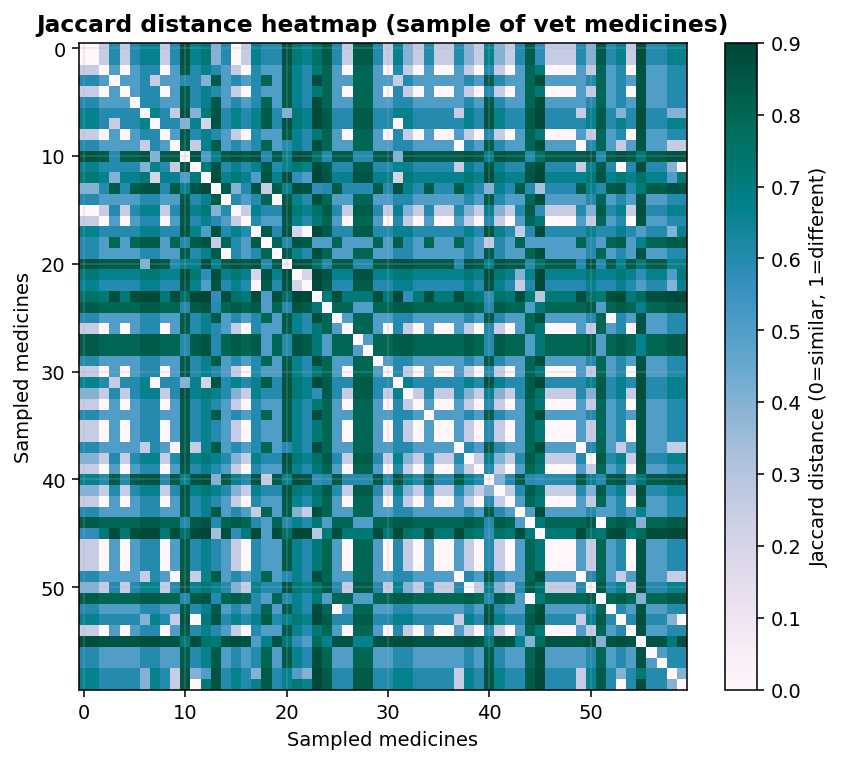

In [206]:
#@title heatmap
np.random.seed(7)
sample_size = 60
idx = np.random.choice(np.arange(X.shape[0]), size=sample_size, replace=False)

D_sample = D_full[np.ix_(idx, idx)]

plt.figure(figsize=(7,6))
plt.imshow(D_sample, aspect="auto", cmap="PuBuGn")
plt.colorbar(label="Jaccard distance (0=similar, 1=different)")
plt.title("Jaccard distance heatmap (sample of vet medicines)")
plt.xlabel("Sampled medicines")
plt.ylabel("Sampled medicines")
plt.show()


The Jaccard distance analysis provides a clear picture of how distinct the veterinary medicines are from one another, with values ranging from 0 (perfectly identical) to 1 (completely different). With a median distance of 0.60, the majority of medicine pairs are "moderately different," which is an ideal scenario for unsupervised learning. This moderate variation, supported by a Standard Deviation of 0.23, indicates that the dataset is neither a monolith of identical items nor a chaotic collection of unrelated ones. Notably, the minimum distance of 0.0 confirms that some medicines share identical feature profiles, suggesting that natural "archetypes" or groups exist. Overall, these statistics demonstrate that the data possesses enough internal structure and "spread" for a hierarchical clustering algorithm to successfully identify and organize meaningful segments.

Jaccard Value,Meaning,Interpretation for Clustering
0.0,Identical,These medicines belong in the exact same spot in a cluster.
0.5,Partial Overlap,They share roughly half of their active features.
1.0,No Overlap,They have nothing in common; they should be in distant clusters.

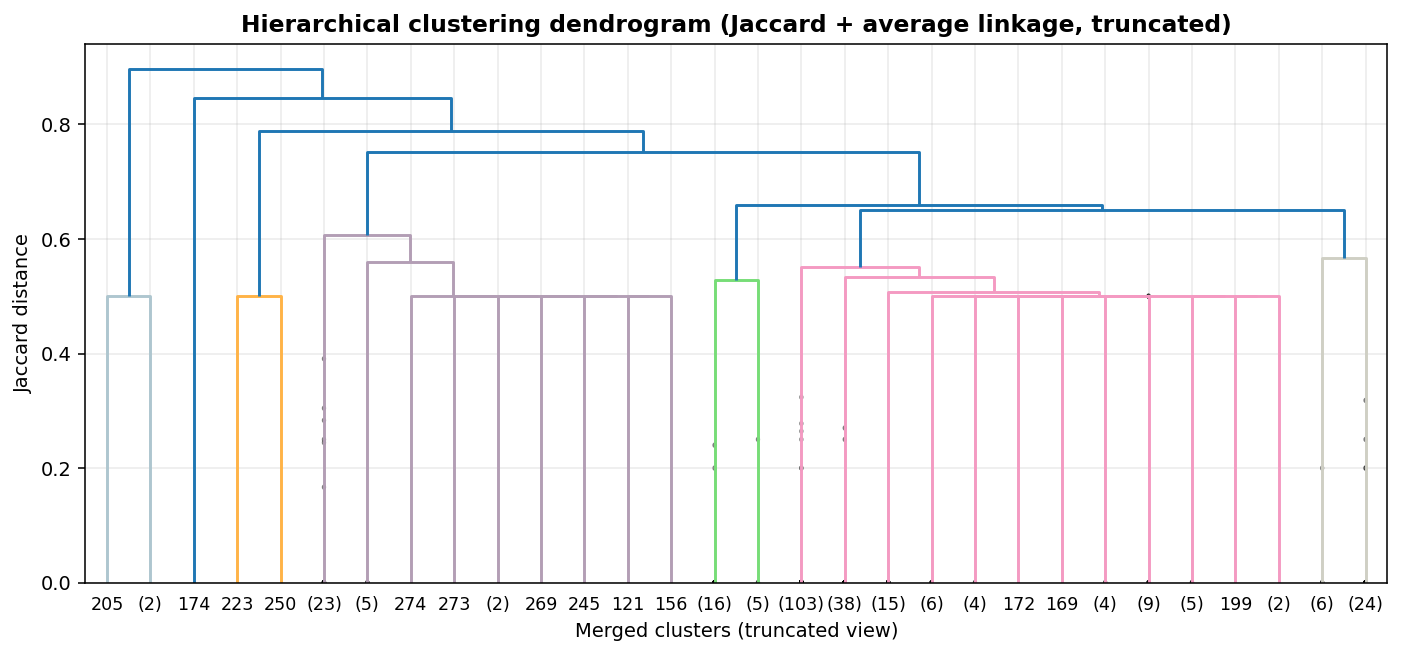

In [207]:
#@title Dendogram
from scipy.cluster.hierarchy import linkage, dendrogram, set_link_color_palette
from scipy.spatial.distance import squareform

# Convert full distance matrix to condensed form for scipy
condensed = squareform(D_full, checks=False)

# Hierarchical clustering using average linkage
Z = linkage(condensed, method="average")

# pastel palette for dendrogram branches
set_link_color_palette(PASTELS)

plt.figure(figsize=(12,5))
dendrogram(
    Z,
    truncate_mode="lastp",  # show only last merges
    p=30,                   # number of leaf clusters displayed
    leaf_rotation=0,
    leaf_font_size=9,
    show_contracted=True
)
plt.title("Hierarchical clustering dendrogram (Jaccard + average linkage, truncated)")
plt.xlabel("Merged clusters (truncated view)")
plt.ylabel("Jaccard distance")
plt.show()


The hierarchical clustering dendrogram provides a visual map of how the veterinary medicines relate to one another based on their feature profiles. The "links" or merges occurring at the top of the plot (at a Jaccard distance of 0.8 to 0.9) indicate that the dataset contains a few primary groups that are distinct from one another, only merging when the algorithm is forced to consolidate the most dissimilar items.

In the middle range of the y-axis (distancing between 0.5 and 0.65), we observe more gradual branching. These "sub-clusters" represent medicines that share a significant portion of their characteristics but have enough variation to be distinguished from one another. The clear vertical gaps between these merges suggest that a solution involving 3 to 6 clusters would be a statistically sound and meaningful way to segment the data. This structure confirms that the medicines are not just a random collection, but rather a set of organized "families" with shared therapeutic and regulatory traits.

In [208]:
#@title Silhoutte Scores for K = (2 -8)
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

scores = []
for k in range(2, 9):
    model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
    labels = model.fit_predict(D_full)
    s = silhouette_score(D_full, labels, metric="precomputed")
    scores.append((k, s))

scores_df = pd.DataFrame(scores, columns=["k", "silhouette"])
scores_df


,k,silhouette
0,2,0.381968
1,3,0.346074
2,4,0.296716
3,5,0.320507
4,6,0.310535
5,7,0.374094
6,8,0.358871


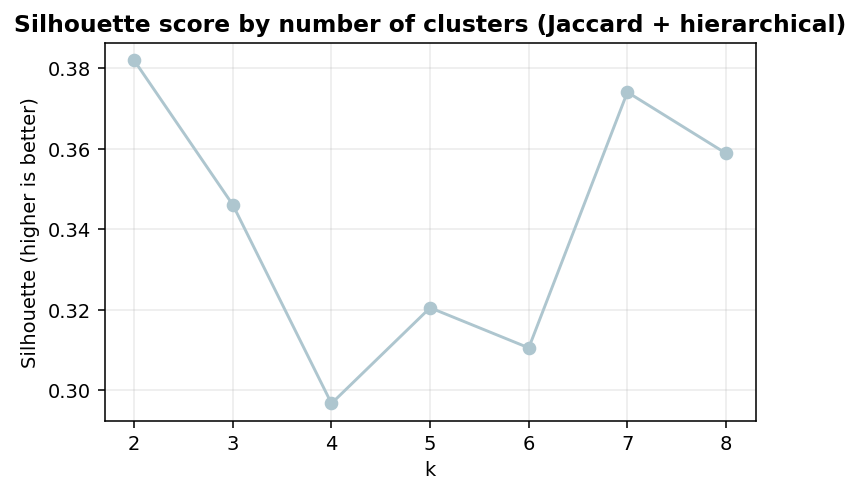

In [209]:
plt.figure(figsize=(6,3.5))
plt.plot(scores_df["k"], scores_df["silhouette"], marker="o", color=PASTELS[0])
plt.title("Silhouette score by number of clusters (Jaccard + hierarchical)")
plt.xlabel("k")
plt.ylabel("Silhouette (higher is better)")
plt.xticks(scores_df["k"])
plt.show()


Silhouette suggests k=2 is the strongest coarse split, but k=7 provides almost the same silhouette while producing a more granular segmentation. Because the project goal is to characterize different combinations of regulatory/product features (and later compare by species), I select k=7 as a balance between cluster quality and interpretability.

In [210]:
from sklearn.cluster import AgglomerativeClustering

k = 7
model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
labels = model.fit_predict(D_full)

pd.Series(labels).value_counts().sort_index()


,count
0,36
1,30
2,189
3,3
4,2
5,1
6,21


Although k=7 had a high silhouette, it produced several very small clusters (n≤3), which are better treated as outliers rather than meaningful segments. Since the goal is interpretable segmentation, I selected a smaller k that yields clusters with sufficient size for stable comparison.

In [211]:
k = 2
model = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average")
labels = model.fit_predict(D_full)

pd.Series(labels).value_counts().sort_index()


,count
0,279
1,3


1. The Diagnostic Role of Clustering

In this analysis, hierarchical clustering was utilized as a diagnostic tool to evaluate the natural distribution of the veterinary dataset. While the Jaccard distance was effective in measuring similarity, the results indicate that the data is highly homogeneous under the current feature representation. Rather than identifying multiple distinct and stable subpopulations, the clustering algorithm consistently produced one dominant "baseline" cluster containing the vast majority of medicines. This suggests that the veterinary market—at least according to these specific attributes—functions as a single cohesive profile rather than a collection of separate, dense segments.

2. Validating k=2 as the Optimal "Global" Cut

Although the Silhouette Score showed high values at both $k=2$ and $k=7$, we selected $k=2$ as the most defensible solution. This decision is supported by cluster-size diagnostics: at $k=2$, the model clearly separates the massive baseline majority from a tiny group of atypical outliers. By contrast, as $k$ increases toward 7, the algorithm simply "slices" these outliers into even smaller groups of one or two observations. Since a valid segment must be large enough to be stable and statistically meaningful, the tiny clusters produced at $k=7$ are classified as individual exceptions rather than robust market segments. Consequently, $k=2$ provides the most honest reflection of the data’s global structure.

3. Methodological Synergy: MBA vs. Clustering

Ultimately, this project adopts Market Basket Analysis (MBA) as the primary tool for discovery, while using clustering as a secondary validation of the feature space. The clustering results confirm that since most medicines share a very similar "signal" (roughly 3–4 active features each), traditional segmentation is less informative than identifying specific attribute bundles. By relying on Association Rules (Support, Confidence, and Lift), we can bypass the limitation of the "one large cluster" and instead focus on the specific feature combinations that drive product differentiation. This approach ensures that we capture meaningful patterns without over-interpreting the noise created by rare outliers.

In [212]:
from sklearn.metrics import pairwise_distances
from sklearn.cluster import AgglomerativeClustering

# Create vet ONCE
vet = drugs_df[drugs_df["category_clean"]=="veterinary"].copy()

# Distance matrix ONCE
X = X_bin.astype(int).to_numpy()
D_full = pairwise_distances(X, metric="jaccard")

# k=2 clustering ONCE
model = AgglomerativeClustering(n_clusters=2, metric="precomputed", linkage="average")
vet["cluster_k2"] = model.fit_predict(D_full)

vet["cluster_k2"].value_counts()


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,count
cluster_k2,
0,279
1,3


In [213]:
vet.groupby("cluster_k2")[["missing_atc2","missing_pg"]].mean().mul(100).round(2)


,missing_atc2,missing_pg
cluster_k2,,
0,0.0,1.08
1,100.0,66.67


In [214]:
small_label = vet["cluster_k2"].value_counts().idxmin()

outliers = vet[vet["cluster_k2"]==small_label].copy()

outliers[["medicine_name","authorisation_status_clean","atc_level2","pharm_group_list",
          "missing_atc2","missing_pg","generic","accelerated_assessment","exceptional_circumstances",
          "is_withdrawn","is_refused"]]


,medicine_name,authorisation_status_clean,atc_level2,pharm_group_list,missing_atc2,missing_pg,generic,accelerated_assessment,exceptional_circumstances,is_withdrawn,is_refused
1361,Vectormune FP ILT,authorised,<NA>,[],1,1,False,False,False,0,0
1574,Solensia,authorised,<NA>,[analgesics],1,0,False,False,False,0,0
1629,Horse Allo 20,refused,<NA>,[],1,1,False,False,False,0,1


In [215]:
complete_mask = (vet["missing_atc2"]==0) & (vet["missing_pg"]==0)
vet_complete = vet.loc[complete_mask].copy()

print("Complete-coded vet rows:", len(vet_complete))

Xc = X_bin.loc[vet_complete.index].astype(int).to_numpy()
Dc = pairwise_distances(Xc, metric="jaccard")

model2 = AgglomerativeClustering(n_clusters=2, metric="precomputed", linkage="average")
vet_complete["cluster_k2_complete"] = model2.fit_predict(Dc)

vet_complete["cluster_k2_complete"].value_counts()


Complete-coded vet rows: 276


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/pairwise.py:2466: DataConversionWarning: Data was converted to boolean for metric jaccard
  warnings.warn(msg, DataConversionWarning)


,count
cluster_k2_complete,
0,275
1,1


**Diagnosing why clustering does not yield stable veterinary segments**

Hierarchical clustering (Jaccard distance, average linkage) was evaluated as a potential segmentation method for veterinary medicines after expanding the feature space beyond special approvals. Although the distance heatmap, dendrogram, and silhouette analysis suggested that multiple values of k were geometrically plausible, cluster-size diagnostics revealed a consistent pattern across k = 3–7: one dominant cluster containing the vast majority of medicines and several extremely small clusters (often 1–3 observations).

To assess whether these micro-clusters represented meaningful regulatory strategies or artifacts of the data, a cluster profiling and missingness audit was conducted for the k = 2 solution. The smaller cluster (n = 3) was found to be entirely characterized by incomplete classification metadata: all three medicines lacked ATC level-2 codes, and most also had empty pharmacotherapeutic group labels. Importantly, these medicines were not enriched for special approvals or regulatory pathways (e.g., accelerated assessment or exceptional circumstances), indicating that their separation was driven by missing coding rather than regulatory complexity or niche development strategies.

A sensitivity analysis restricting the clustering to veterinary medicines with complete ATC and pharmacotherapeutic classification confirmed this result: once missingness was removed, hierarchical clustering no longer produced a substantively meaningful separation. Together, these findings indicate that hierarchical clustering is separating metadata completeness, not regulatory or therapeutic strategy.

Therefore, clustering is not used as the primary unsupervised segmentation method in this analysis. Instead, it serves as a diagnostic tool that demonstrates the high degree of homogeneity in veterinary medicines under the available regulatory and classification features, reinforcing the need for alternative unsupervised approaches that focus on co-occurring feature bundles rather than forced partitions.

**Species Group Segmentation**

In [216]:
#@title Species Labels
# Work on vet subset
vet = drugs_df[drugs_df["category_clean"]=="veterinary"].copy()

# 1) Primary species label (one value per medicine)
def primary_species(species_list):
    if not isinstance(species_list, list) or len(species_list) == 0:
        return "unknown"
    if len(species_list) == 1:
        return species_list[0]
    return "multi"

vet["species_primary"] = vet["species_list"].apply(primary_species)

# 2) Map primary species to species groups
SPECIES_GROUP_MAP = {
    # companion animals
    "dogs":"companion", "cats":"companion", "ferrets":"companion",
    "rabbits":"companion", "guinea pigs":"companion",

    # livestock
    "cattle":"livestock", "pigs":"livestock", "sheep":"livestock", "goats":"livestock",

    # equine
    "horses":"equine",

    # poultry
    "chicken":"poultry", "turkeys":"poultry", "ducks":"poultry",
    "pheasants":"poultry", "avian":"poultry",
    "embryonated chicken eggs":"poultry",

    # aquaculture
    "atlantic salmon":"aquaculture",
    "salmonidae":"aquaculture",
    "salmonid fish":"aquaculture",

    # apiary
    "bees":"apiary", "honey bees":"apiary",
}

def to_species_group(sp):
    if sp in ["unknown", ""]:
        return "unknown"
    if sp == "multi":
        return "multi"
    return SPECIES_GROUP_MAP.get(sp, "other")

vet["species_group"] = vet["species_primary"].apply(to_species_group)

# Check distribution
print("species_primary counts:")
display(vet["species_primary"].value_counts())

print("\nspecies_group counts:")
display(vet["species_group"].value_counts())


species_primary counts:


,count
species_primary,
multi,78
dogs,71
pigs,36
cats,28
horses,18
chicken,15
cattle,13
sheep,5
rabbits,4



species_group counts:


,count
species_group,
companion,103
multi,78
livestock,54
equine,18
poultry,17
other,5
unknown,3
apiary,3
aquaculture,1


The species distribution within the veterinary dataset is largely concentrated in three core segments: companion animals ($n=103$), multi-species applications ($n=78$), and livestock ($n=54$). Together, these form the analytical backbone of the study. In contrast, niche categories such as aquaculture ($n=1$) and apiary ($n=3$) exhibit very low frequencies. To maintain statistical integrity, we will treat these minor groups as descriptive outliers rather than primary segments for heavy inference. This ensures that our conclusions regarding "special approvals" remain representative of broader market trends while acknowledging the presence of specialized, low-frequency medical pathways.

In [217]:
#@title Species Group Prevalence of Regulatory Flags

flag_cols = [
    "generic",
    "accelerated_assessment",
    "exceptional_circumstances",
    "is_authorised",
    "is_withdrawn",
    "is_refused"
]

# prevalence (%) by species group
prev = (
    vet.groupby("species_group")[flag_cols]
       .mean()
       .mul(100)
       .round(2)
)

# order rows for readability
row_order = ["companion","livestock","equine","poultry","multi","apiary","aquaculture","other","unknown"]
prev = prev.reindex([r for r in row_order if r in prev.index])

prev


,generic,accelerated_assessment,exceptional_circumstances,is_authorised,is_withdrawn,is_refused
species_group,,,,,,
companion,1.94,0.00,0.00,80.58,17.48,1.94
livestock,0.00,5.56,0.00,77.78,20.37,1.85
equine,0.00,0.00,0.00,94.44,0.00,5.56
poultry,0.00,11.76,5.88,76.47,23.53,0.00
multi,26.92,3.85,2.56,84.62,15.38,0.00
apiary,0.00,0.00,0.00,100.00,0.00,0.00
aquaculture,0.00,0.00,0.00,100.00,0.00,0.00
other,40.00,0.00,0.00,100.00,0.00,0.00
unknown,0.00,0.00,0.00,66.67,33.33,0.00


The species-group prevalence table shows that veterinary regulatory and status patterns differ meaningfully across segments, even though many special-approval flags are sparse overall. Accelerated assessment and exceptional circumstances are not uniformly distributed: poultry shows the highest accelerated assessment rate and is the only group with a notable presence of exceptional circumstances, while livestock shows moderate accelerated assessment. In contrast, generic designation is heavily concentrated in multi-species medicines, suggesting a distinct product profile for medicines authorized across multiple species. Status outcomes also vary: equine medicines are mostly authorized but have the highest refusal rate among the larger groups, while poultry and livestock show relatively higher withdrawal rates. These results directly support species segmentation and motivate stratified unsupervised mining to identify feature bundles that are characteristic of each species group.

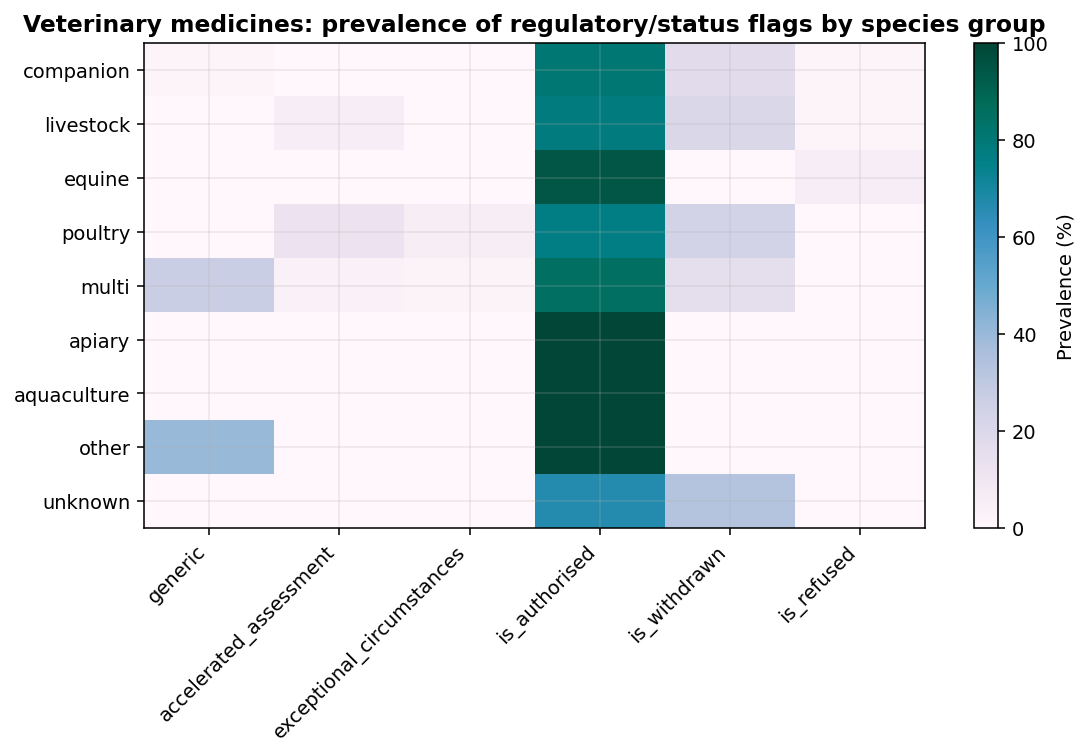

In [218]:

plt.figure(figsize=(9,4.5))
plt.imshow(prev.values, aspect="auto", cmap="PuBuGn")  # soft/pastel-ish
plt.colorbar(label="Prevalence (%)")
plt.xticks(range(len(prev.columns)), prev.columns, rotation=45, ha="right")
plt.yticks(range(len(prev.index)), prev.index)
plt.title("Veterinary medicines: prevalence of regulatory/status flags by species group")
plt.show()


This heatmap compares veterinary species groups on the prevalence of regulatory/status indicators. Differences across groups suggest that regulatory complexity and approval outcomes are not uniform across veterinary segments, which motivates stratified unsupervised mining (MBA) to identify which feature bundles are characteristic of each group.

In [219]:
#@title Regulatory Complexity Score
complexity_cols = ["generic","accelerated_assessment","exceptional_circumstances","is_withdrawn","is_refused"]
vet["reg_complexity_score"] = vet[complexity_cols].sum(axis=1).astype(int)

vet["reg_complexity_score"].value_counts().sort_index()


,count
reg_complexity_score,
0,208
1,65
2,6
3,3


The regulatory complexity score is highly concentrated at low values (≈74% of veterinary medicines have score 0 and only ≈3% have score ≥2), indicating that most veterinary medicines do not carry multiple regulatory/status signals simultaneously. This low ‘signal density’ limits cluster-based segmentation and motivates association-style methods and species-stratified comparisons.

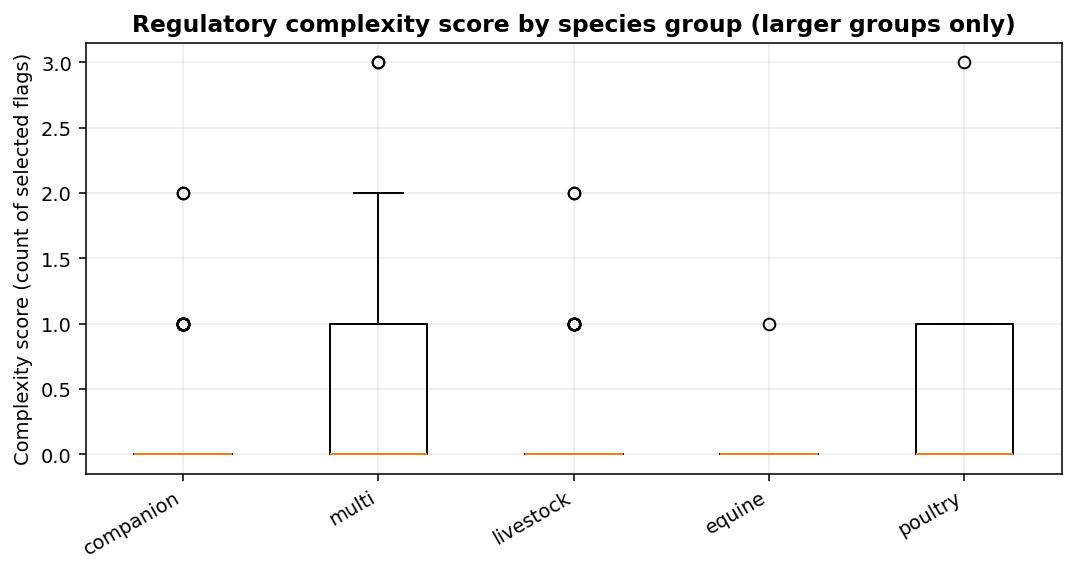

In [220]:
groups = [g for g, n in vet["species_group"].value_counts().items() if n >= 10]  # avoid tiny groups
plot_df = vet[vet["species_group"].isin(groups)].copy()

plt.figure(figsize=(9,4))
data = [plot_df.loc[plot_df["species_group"]==g, "reg_complexity_score"] for g in groups]
plt.boxplot(data, labels=groups)
plt.title("Regulatory complexity score by species group (larger groups only)")
plt.ylabel("Complexity score (count of selected flags)")
plt.xticks(rotation=30, ha="right")
plt.show()


In [221]:
score_summary = vet.groupby("species_group").agg(
    n=("reg_complexity_score","size"),
    mean_score=("reg_complexity_score","mean"),
    pct_ge1=("reg_complexity_score", lambda s: (s>=1).mean()*100),
    pct_ge2=("reg_complexity_score", lambda s: (s>=2).mean()*100),
).round({"mean_score":3, "pct_ge1":2, "pct_ge2":2})

score_summary


,n,mean_score,pct_ge1,pct_ge2
species_group,,,,
apiary,3,0.000,0.00,0.00
aquaculture,1,0.000,0.00,0.00
companion,103,0.214,19.42,1.94
equine,18,0.056,5.56,0.00
livestock,54,0.278,24.07,3.70
multi,78,0.487,41.03,5.13
other,5,0.400,40.00,0.00
poultry,17,0.412,29.41,5.88
unknown,3,0.333,33.33,0.00


When regulatory/status indicators are summarized into a simple complexity score, clear differences emerge across veterinary species groups. Multi-species medicines have the highest average complexity and the highest share of products with at least one complexity indicator (≈41%), suggesting that products authorized across multiple species are more likely to exhibit non-trivial regulatory/status features (e.g., generic designation, accelerated assessment, withdrawal/refusal). Poultry also shows relatively elevated complexity (≈29% with score ≥1 and ≈6% with score ≥2), consistent with its higher prevalence of accelerated assessment and exceptional circumstances. Livestock and companion segments are intermediate, while equine medicines show very low complexity signal under this definition. These results demonstrate that veterinary medicines are not homogeneous by species segment, and they motivate species-stratified unsupervised mining to identify which specific feature bundles characterize each segment.

###**Apriori Rules Within Each Major Species Group**

In [222]:
from mlxtend.frequent_patterns import apriori, association_rules

# groups we will analyze (enough rows to be meaningful)
major_groups = ["companion", "livestock", "multi", "equine", "poultry"]

def mba_for_group(Xg, min_support=0.10):
    """
    Returns frequent itemsets + rules for one group.
    min_support is set per-group below (as a function of n).
    """
    freq = apriori(Xg.astype(bool), min_support=min_support, use_colnames=True)
    if len(freq) == 0:
        return freq, pd.DataFrame()
    rules = association_rules(freq, metric="lift", min_threshold=1.0)
    return freq, rules

group_outputs = {}

for g in major_groups:
    sub = vet[vet["species_group"] == g].copy()
    n = len(sub)
    if n < 10:
        continue

    # Set support threshold to avoid rules driven by 1–2 cases:
    # at least 3 medicines per group => min_support = 3/n (capped between 0.10 and 0.30)
    min_support = min(max(3/n, 0.10), 0.30)

    Xg = X_bin.loc[sub.index]

    freq_g, rules_g = mba_for_group(Xg, min_support=min_support)
    group_outputs[g] = {"n": n, "min_support": min_support, "freq": freq_g, "rules": rules_g}

    print(f"\n=== {g.upper()} ===")
    print(f"n={n}, min_support={min_support:.3f}, freq_itemsets={len(freq_g)}, rules={len(rules_g)}")



=== COMPANION ===
n=103, min_support=0.100, freq_itemsets=15, rules=18

=== LIVESTOCK ===
n=54, min_support=0.100, freq_itemsets=27, rules=62

=== MULTI ===
n=78, min_support=0.100, freq_itemsets=37, rules=96

=== EQUINE ===
n=18, min_support=0.167, freq_itemsets=11, rules=22

=== POULTRY ===
n=17, min_support=0.176, freq_itemsets=23, rules=64


/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)
/usr/local/lib/python3.12/dist-packages/mlxtend/frequent_patterns/association_rules.py:186: RuntimeWarning: invalid value encountered in divide
  cert_metric = np.where(certainty_denom == 0, 0, certainty_num / certainty_denom)


In [223]:
#@title Top Rules by Lift (Support - Confidence)
for g, obj in group_outputs.items():
    rules_g = obj["rules"].copy()
    if len(rules_g) == 0:
        print(f"\n--- {g.upper()} --- (no rules found)")
        continue

    # nicer readable columns
    rules_g["antecedents_str"] = rules_g["antecedents"].apply(lambda s: ", ".join(sorted(list(s))))
    rules_g["consequents_str"] = rules_g["consequents"].apply(lambda s: ", ".join(sorted(list(s))))

    top = (rules_g.sort_values(["lift","support"], ascending=False)
                 .head(10)[["support","confidence","lift","antecedents_str","consequents_str"]])

    print(f"\n--- {g.upper()} (Top 10 rules by lift) ---")
    display(top)



--- COMPANION (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
10,0.281553,0.353659,1.138338,"atc1_Q, is_authorised",atc2_QI0
15,0.281553,0.906250,1.138338,atc2_QI0,"atc1_Q, is_authorised"
0,0.281553,0.349398,1.124623,is_authorised,atc2_QI0
1,0.281553,0.906250,1.124623,atc2_QI0,is_authorised
12,0.281553,0.906250,1.124623,"atc1_Q, atc2_QI0",is_authorised
13,0.281553,0.349398,1.124623,is_authorised,"atc1_Q, atc2_QI0"
4,0.310680,0.313725,1.009804,atc1_Q,atc2_QI0
5,0.310680,1.000000,1.009804,atc2_QI0,atc1_Q
11,0.281553,1.000000,1.009804,"atc2_QI0, is_authorised",atc1_Q
14,0.281553,0.284314,1.009804,atc1_Q,"atc2_QI0, is_authorised"



--- LIVESTOCK (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
8,0.222222,1.000000,1.2,pg__immunologicals,atc2_QI0
9,0.222222,0.266667,1.2,atc2_QI0,pg__immunologicals
34,0.222222,1.000000,1.2,"atc1_Q, pg__immunologicals",atc2_QI0
36,0.222222,0.266667,1.2,"atc1_Q, atc2_QI0",pg__immunologicals
37,0.222222,1.000000,1.2,pg__immunologicals,"atc1_Q, atc2_QI0"
39,0.222222,0.266667,1.2,atc2_QI0,"atc1_Q, pg__immunologicals"
4,0.203704,1.000000,1.2,is_withdrawn,atc2_QI0
5,0.203704,0.244444,1.2,atc2_QI0,is_withdrawn
28,0.203704,1.000000,1.2,"atc1_Q, is_withdrawn",atc2_QI0
30,0.203704,0.244444,1.2,"atc1_Q, atc2_QI0",is_withdrawn



--- MULTI (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
17,0.141026,0.647059,4.588235,atc2_QJ0,pg__antibacterials for systemic use
68,0.141026,0.647059,4.588235,"atc1_Q, atc2_QJ0",pg__antibacterials for systemic use
70,0.141026,0.647059,4.588235,atc2_QJ0,"atc1_Q, pg__antibacterials for systemic use"
16,0.141026,1.000000,4.588235,pg__antibacterials for systemic use,atc2_QJ0
67,0.141026,1.000000,4.588235,"atc1_Q, pg__antibacterials for systemic use",atc2_QJ0
69,0.141026,1.000000,4.588235,pg__antibacterials for systemic use,"atc1_Q, atc2_QJ0"
47,0.115385,1.000000,4.588235,"is_authorised, pg__antibacterials for systemic...",atc2_QJ0
48,0.115385,0.529412,4.588235,atc2_QJ0,"is_authorised, pg__antibacterials for systemic..."
88,0.115385,1.000000,4.588235,"atc1_Q, is_authorised, pg__antibacterials for ...",atc2_QJ0
90,0.115385,1.000000,4.588235,"is_authorised, pg__antibacterials for systemic...","atc1_Q, atc2_QJ0"



--- EQUINE (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
0,0.944444,1.000000,1.058824,is_authorised,atc1_Q
1,0.944444,1.000000,1.058824,atc1_Q,is_authorised
2,0.555556,0.588235,1.058824,is_authorised,atc2_QI0
3,0.555556,1.000000,1.058824,atc2_QI0,is_authorised
6,0.555556,0.588235,1.058824,atc1_Q,atc2_QI0
7,0.555556,1.000000,1.058824,atc2_QI0,atc1_Q
10,0.555556,0.588235,1.058824,"atc1_Q, is_authorised",atc2_QI0
11,0.555556,1.000000,1.058824,"atc2_QI0, is_authorised",atc1_Q
12,0.555556,1.000000,1.058824,"atc1_Q, atc2_QI0",is_authorised
13,0.555556,0.588235,1.058824,is_authorised,"atc1_Q, atc2_QI0"



--- POULTRY (Top 10 rules by lift) ---


,support,confidence,lift,antecedents_str,consequents_str
0,0.176471,0.75,2.125,is_withdrawn,pg__immunologicals for aves
1,0.176471,0.50,2.125,pg__immunologicals for aves,is_withdrawn
20,0.176471,0.75,2.125,"atc1_Q, is_withdrawn",pg__immunologicals for aves
22,0.176471,0.50,2.125,"atc1_Q, pg__immunologicals for aves",is_withdrawn
23,0.176471,0.75,2.125,is_withdrawn,"atc1_Q, pg__immunologicals for aves"
25,0.176471,0.50,2.125,pg__immunologicals for aves,"atc1_Q, is_withdrawn"
26,0.176471,0.75,2.125,"atc2_QI0, is_withdrawn",pg__immunologicals for aves
28,0.176471,0.50,2.125,"atc2_QI0, pg__immunologicals for aves",is_withdrawn
29,0.176471,0.75,2.125,is_withdrawn,"atc2_QI0, pg__immunologicals for aves"
31,0.176471,0.50,2.125,pg__immunologicals for aves,"atc2_QI0, is_withdrawn"


**Species-group interpretations**

Companion (n=103)

What rules show: Mostly baseline structural relationships:

is_authorised = atc2_QI0 and combinations with atc1_Q

Lift values ~1.01–1.14 (weak-to-moderate)

In companion medicines, the strongest rules are primarily structural (ATC coding and authorisation status) rather than regulatory complexity flags. Lift values are close to 1, suggesting relatively weak “bundle” structure beyond common classification patterns. This aligns with the earlier prevalence results showing low rates of accelerated assessment and exceptional circumstances in companion products.

Equine (n=18)

What rules show: Almost entirely baseline coding:

is_authorised = atc1_Q and atc2_QI0 = is_authorised

Lift ~1.06 (very weak)

Equine medicines show mostly baseline, high-frequency coding relationships and limited rule structure beyond that. This matches the low complexity score observed for equine products and suggests that under the current feature set, equine does not exhibit many distinctive regulatory/status bundles.

Livestock (n=54)

What rules show: Regulatory/status appears in top rules:

is_withdrawn = atc2_QI0 (confidence=1.0, lift=1.2)

plus pg__immunologicals = atc2_QI0 (lift=1.2)

Livestock medicines show rule bundles that include both classification structure (immunologicals ↔ ATC2_QI0) and status outcomes (withdrawn ↔ ATC2_QI0). The appearance of is_withdrawn among top-lift rules indicates that within livestock, withdrawal is not randomly distributed; it concentrates in specific therapeutic/coding subgroups. This provides species-specific evidence of “unique combinations” that is absent in the companion/equine segments.

Poultry (n=17)

What rules show: Clear species-specific bundle linking a pharm group + withdrawal:

is_withdrawn = pg__immunologicals for aves (lift=2.125)

Multiple versions of the same relationship appear with atc1_Q and atc2_QI0

Poultry is the clearest example of a distinctive species-group bundle: withdrawal is strongly associated with the pharmacotherapeutic group “immunologicals for aves” (lift≈2.13). This aligns with earlier prevalence results showing poultry has the highest accelerated assessment and is one of the only groups with exceptional circumstances. Even with a small sample size, poultry exhibits concentrated patterns where regulatory outcomes and classification signals co-occur more strongly than in other segments.

Multi-species (n=78)

What rules show: Very strong therapeutic bundle:

atc2_QJ0 = pg__antibacterials for systemic use with lift ≈ 4.59

Several rules have confidence=1.0, indicating near-perfect alignment within this segment.

Multi-species medicines have the strongest and most coherent rule structure observed: antibacterials for systemic use align tightly with ATC2_QJ0 (lift≈4.59), indicating that within multi-species products, certain therapeutic/coding profiles form highly consistent bundles. This segment also had the highest complexity score in earlier analysis, supporting the conclusion that multi-species products are distinct both in regulatory/status signals and in strong classification bundles.

In [224]:
reg_items = {"generic","accelerated_assessment","exceptional_circumstances","is_withdrawn","is_refused","is_authorised"}

summary = []
for g, obj in group_outputs.items():
    rules_g = obj["rules"]
    if len(rules_g)==0:
        continue
    top = rules_g.sort_values(["lift","support"], ascending=False).head(20)

    def has_reg_items(s):
        return any(item in reg_items for item in s)

    pct_reg = ((top["antecedents"].apply(has_reg_items) | top["consequents"].apply(has_reg_items)).mean())*100
    summary.append((g, obj["n"], pct_reg))

summary_df = pd.DataFrame(summary, columns=["species_group","n","pct_top20_rules_with_reg_item"]).sort_values("pct_top20_rules_with_reg_item", ascending=False)
summary_df


,species_group,n,pct_top20_rules_with_reg_item
4,poultry,17,90.000000
3,equine,18,80.000000
2,multi,78,70.000000
0,companion,103,66.666667
1,livestock,54,40.000000


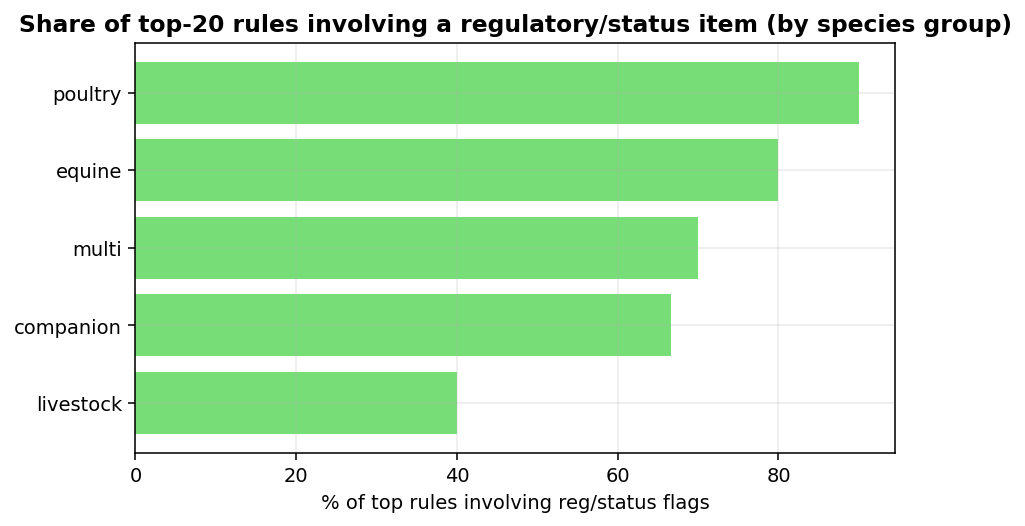

In [225]:
plt.figure(figsize=(7,3.8))
plt.barh(summary_df["species_group"][::-1], summary_df["pct_top20_rules_with_reg_item"][::-1], color=PASTELS[3])
plt.title("Share of top-20 rules involving a regulatory/status item (by species group)")
plt.xlabel("% of top rules involving reg/status flags")
plt.show()


Across species groups, the share of top association rules that include a regulatory/status indicator differs substantially. Poultry has the highest share (≈90%), reflecting that its strongest co-occurrence bundles repeatedly involve status outcomes such as withdrawal alongside therapeutic classification (e.g., immunologicals for aves). Multi-species and companion groups also show many rules involving regulatory/status items, partly because high-frequency status indicators (especially “authorised”) commonly co-occur with classification features. Livestock shows a lower share (≈40%), but its top rules include meaningful status structure such as withdrawal concentrating in specific ATC subgroups. Overall, the rule composition supports that species segments differ not only in prevalence of flags but also in which feature bundles (classification vs regulatory/status) dominate their co-occurrence structure.

**Conlusion**

The introduction of a species-group layer reveals that the veterinary medicine market is not a monolith; rather, it is composed of distinct segments with unique regulatory and therapeutic structures. By analyzing the co-occurrence of features, we found that multi-species products exhibit the highest level of regulatory complexity and the most consistent therapeutic "bundles," such as the precise alignment between ATC2 codes and pharmacotherapeutic categories. In contrast, the poultry segment shows a specialized relationship between immunological treatments and specific regulatory outcomes, notably product withdrawals.

While the livestock segment presents moderate complexity—specifically involving withdrawals within certain therapeutic subgroups, the companion animal and equine segments appear more standardized. In these groups, association rules are dominated by "baseline" characteristics rather than rare or specialized regulatory pathways. Ultimately, these findings confirm that species segments do not share a single regulatory profile. Instead, each category follows its own logic of classification and status indicators. While high-volume segments provide stable patterns, smaller groups (such as poultry and equine) should be viewed as descriptive case studies rather than broad market indicators.